# PCA and Factor Analysis for Indian Quantitative Finance
## A Comprehensive Research Framework for NSE/BSE Markets

**Author:** Aman Singh (BS2308)  
**Date:** April 2026  
**Project:** Statistical Methods IV - PCA Research on Indian Markets

---

## Executive Summary

This notebook explores six major research questions using Indian stock market data:

1. **COVID-19 Structural Break Analysis**: Did the principal component structure of Indian equities change during/after the pandemic?
2. **Factor Discovery**: Can PCA identify new factors relevant in the post-pandemic Indian economy?
3. **Factor-Sector Relationships**: How do factor exposures relate to Indian sector performance?
4. **Sector Rotation Strategy**: Building a PCA-based tactical sector allocation system for Indian markets
5. **Factor Stability Analysis**: How stable are factor loadings across market regimes in India?
6. **Alpha Pooling & Meta-Strategies**: Using PCA on a technical alpha library to study latent strategy factors and test meta-strategy construction

---

## Table of Contents

1. [Setup & Imports](#setup)
2. [Data Collection](#data)
3. [Helper Functions](#helpers)
4. [Research Question 1: COVID Structural Break](#rq1)
5. [Research Question 2: New Factor Discovery](#rq2)
6. [Research Question 3: Factor-Sector Analysis](#rq3)
7. [Research Question 4: Sector Rotation Strategy](#rq4)
8. [Research Question 5: Factor Stability](#rq5)
9. [Research Question 6: Alpha Pooling](#rq6)
10. [Conclusions](#conclusions)

<a id='setup'></a>
## 1. Setup & Imports

In [73]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from scipy import stats
from scipy.stats import f, ttest_ind
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Financial data
import yfinance as yf
# from fredapi import Fred

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
np.random.seed(42)

print("✓ All libraries imported successfully")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Current date: {datetime.now().strftime('%Y-%m-%d')}")

✓ All libraries imported successfully
✓ NumPy version: 2.2.6
✓ Pandas version: 2.2.3
✓ Current date: 2026-04-04


### Data Collection

We'll collect:
- **NSE Nifty 50 and Large-cap constituents** (top 50 stocks by market cap from Indian market)
- **Sector Indices** (Banking, IT, Auto, Pharma, Energy, FMCG, etc.)
- **Fundamental data** (P/E, P/B, ROE, etc. from NSE/BSE sources)
- **Macro indicators** (RBI rates, inflation, GDP - when available)

In [75]:
# Date ranges
START_DATE = '2015-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')
COVID_BREAK = '2020-03-01'  # COVID market crash (also relevant for Indian markets)

# NSE/BSE large-cap stocks with Yahoo Finance compatible NSE symbols

# 
def get_nifty50_yahoo_symbols():
    import requests
    
    url = "https://www.nseindia.com/api/equity-stockIndices?index=NIFTY%2050"
    headers = {"User-Agent": "Mozilla/5.0"}
    
    s = requests.Session()
    s.get("https://www.nseindia.com", headers=headers)
    data = s.get(url, headers=headers).json()
    
    return [x["symbol"] + ".NS" for x in data["data"]]

# NIFTY_TICKERS = get_nifty50_yahoo_symbols()
# print(NIFTY_TICKERS[:50])

NIFTY_TICKERS = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
    'WIPRO.NS', 'HINDUNILVR.NS', 'BAJAJFINSV.NS', 'MARUTI.NS', 'BHARTIARTL.NS',
    'SBIN.NS', 'KOTAKBANK.NS', 'ASIANPAINT.NS', 'DMART.NS', 'TITAN.NS',
    'ULTRACEMCO.NS', 'NESTLEIND.NS', 'POWERGRID.NS', 'JSWSTEEL.NS', 'BAJAJ-AUTO.NS',
    'LT.NS', 'INDUSINDBK.NS', 'AXISBANK.NS', 'SUNPHARMA.NS', 'DRREDDY.NS',
    'HCLTECH.NS', 'TECHM.NS', 'DIVISLAB.NS', 'EICHERMOT.NS', 'ADANIPORTS.NS',
    'ADANIENT.NS', 'HEROMOTOCO.NS', 'BPCL.NS', 'HINDPETRO.NS', 'TRENT.NS',
    'M&M.NS', 'NTPC.NS', 'COALINDIA.NS', 'IOC.NS', 'GAIL.NS',
    'CIPLA.NS', 'LUPIN.NS', 'TORNTPHARM.NS', 'BRITANNIA.NS', 'ITC.NS',
    'SHREECEM.NS', 'SIEMENS.NS', 'FEDERALBNK.NS', 'ONGC.NS', 'INDIGO.NS'
]

# Sector series with Yahoo symbol fallbacks.
# Keys are the final column names used throughout the notebook.
SECTOR_ETFS = {
    'Banking': ['^NSEBANK', '^CNXBANK', 'BANKBEES.NS'],
    'Infrastructure': ['^CNXINFRA'],
    'IT/Technology': ['^CNXIT', 'ITBEES.NS'],
    'Automobiles': ['^CNXAUTO'],
    'Pharmaceuticals': ['^CNXPHARMA'],
    'Energy': ['^CNXENERGY'],
    'Power': ['^CNXENERGY'],
    'FMCG': ['^CNXFMCG', 'CONSUMBEES.NS'],
    'Metals': ['^CNXMETAL'],
    'Realty': ['^CNXREALTY'],
    'Financial Services': ['NIFTY_FIN_SERVICE.NS', '^CNXFINSERVICE', 'FINNIFTY.NS']
}

print(f"Configuration:")
print(f"  Period: {START_DATE} to {END_DATE}")
print(f"  COVID Break: {COVID_BREAK}")
print(f"  NSE/BSE Stocks: {len(NIFTY_TICKERS)}")
print(f"  Sector Indices: {len(SECTOR_ETFS)}")

Configuration:
  Period: 2015-01-01 to 2026-04-04
  COVID Break: 2020-03-01
  NSE/BSE Stocks: 50
  Sector Indices: 11


In [76]:
def _extract_price_series(raw_data, column_name):
    """Extract a single adjusted-close style series from a yfinance response."""
    if raw_data is None or raw_data.empty:
        return None

    if isinstance(raw_data.columns, pd.MultiIndex):
        first_level = raw_data.columns.get_level_values(0)
        if 'Adj Close' in first_level:
            series = raw_data['Adj Close']
        elif 'Close' in first_level:
            series = raw_data['Close']
        else:
            return None

        if isinstance(series, pd.DataFrame):
            series = series.iloc[:, 0]
    else:
        price_col = 'Adj Close' if 'Adj Close' in raw_data.columns else 'Close'
        if price_col not in raw_data.columns:
            return None
        series = raw_data[price_col]

    series = series.dropna()
    if series.empty:
        return None

    return series.rename(column_name)

def download_price_data(tickers, start, end, min_history_ratio=0.6):
    """
    Download adjusted close prices for given tickers.
    
    Parameters:
    -----------
    tickers : list or dict
        List of ticker symbols or a mapping of output labels to candidate Yahoo symbols
    start : str
        Start date (YYYY-MM-DD)
    end : str
        End date (YYYY-MM-DD)
    min_history_ratio : float
        Minimum non-null history required to keep a series
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with adjusted close prices
    """
    print(f"Downloading price data for {len(tickers)} tickers...")

    if isinstance(tickers, dict):
        download_plan = [
            (label, candidates if isinstance(candidates, (list, tuple)) else [candidates])
            for label, candidates in tickers.items()
        ]
    else:
        download_plan = [(ticker, [ticker]) for ticker in tickers]

    frames = []
    failed = {}

    for label, candidates in download_plan:
        series = None
        last_error = None

        for symbol in candidates:
            try:
                raw_data = yf.download(
                    symbol,
                    start=start,
                    end=end,
                    progress=False,
                    auto_adjust=False,
                    actions=False,
                    threads=False
                )
                series = _extract_price_series(raw_data, label)
                if series is not None:
                    break
            except Exception as exc:
                last_error = str(exc)

        if series is None:
            failed[label] = {
                'candidates': candidates,
                'error': last_error
            }
            continue

        frames.append(series)

    if not frames:
        raise ValueError('No valid price series were downloaded. Please review the ticker list.')

    data = pd.concat(frames, axis=1).sort_index()
    min_obs = max(1, int(np.ceil(min_history_ratio * len(data))))
    original_columns = data.columns.tolist()
    data = data.dropna(axis=1, thresh=min_obs)
    dropped_for_history = sorted(set(original_columns) - set(data.columns))
    data = data.ffill()

    print(f"  ✓ Downloaded {len(data.columns)} tickers successfully")
    print(f"  ✓ Date range: {data.index[0].date()} to {data.index[-1].date()}")
    print(f"  ✓ Total observations: {len(data)}")

    if failed:
        print(f"  • Skipped {len(failed)} unavailable tickers/sectors: {', '.join(failed.keys())}")

    if dropped_for_history:
        print(f"  • Dropped {len(dropped_for_history)} series with insufficient history: {', '.join(dropped_for_history)}")

    return data

# Download Indian stock prices
nifty_prices = download_price_data(NIFTY_TICKERS, START_DATE, END_DATE)

# Download sector index prices
sector_prices = download_price_data(SECTOR_ETFS, START_DATE, END_DATE)

  ✓ Downloaded 50 tickers successfully
  ✓ Date range: 2015-01-01 to 2026-04-02
  ✓ Total observations: 2778
  ✓ Downloaded 11 tickers successfully
  ✓ Date range: 2015-01-01 to 2026-04-02
  ✓ Total observations: 2774


In [77]:
def calculate_returns(prices, frequency='D', min_history_ratio=0.6):
    """
    Calculate returns from prices
    
    Parameters:
    -----------
    prices : pd.DataFrame
        DataFrame of prices
    frequency : str
        'D' for daily, 'W' for weekly, 'M' for monthly
    
    Returns:
    --------
    pd.DataFrame
        DataFrame of returns
    """
    if prices is None or prices.empty:
        raise ValueError('Price data is empty. Re-run the download cell and inspect failed tickers.')

    if frequency != 'D':
        prices = prices.resample(frequency).last()

    returns = prices.pct_change(fill_method=None)
    returns = returns.replace([np.inf, -np.inf], np.nan)
    min_obs = max(1, int(np.ceil(min_history_ratio * len(returns))))
    returns = returns.dropna(axis=1, thresh=min_obs).dropna()
    return returns

# Calculate monthly returns for main analysis
nifty_returns = calculate_returns(nifty_prices, 'M')
sector_returns = calculate_returns(sector_prices, 'M')

print(f"\nReturns Summary:")
print(f"  Nifty returns shape: {nifty_returns.shape}")
print(f"  Sector returns shape: {sector_returns.shape}")
print(f"  Period: {nifty_returns.index[0].date()} to {nifty_returns.index[-1].date()}")


Returns Summary:
  Nifty returns shape: (109, 50)
  Sector returns shape: (135, 11)
  Period: 2017-04-30 to 2026-04-30


### Calculate Characteristics

We'll calculate key investment characteristics for our stocks:
- **Value**: P/E, P/B, Dividend Yield
- **Momentum**: 1M, 3M, 6M, 12M returns
- **Volatility**: 20-day, 60-day realized vol
- **Quality**: ROE, Gross Margin (when fundamental data available)

For this demo, we'll focus on price-volume characteristics that can be computed from market data.

In [78]:
def calculate_characteristics(prices, returns):
    """
    Calculate investment characteristics from price and return data
    
    Parameters:
    -----------
    prices : pd.DataFrame
        Daily price data
    returns : pd.DataFrame
        Monthly return data
    
    Returns:
    --------
    pd.DataFrame
        Characteristics matrix (time x stocks x characteristics)
    """
    print("Calculating investment characteristics...")
    
    characteristics = {}
    
    # Resample prices to monthly
    monthly_prices = prices.resample('M').last()
    daily_returns = prices.pct_change()
    
    # Momentum features
    characteristics['momentum_1m'] = monthly_prices.pct_change(1)
    characteristics['momentum_3m'] = monthly_prices.pct_change(3)
    characteristics['momentum_6m'] = monthly_prices.pct_change(6)
    characteristics['momentum_12m'] = monthly_prices.pct_change(12)
    
    # Volatility features (computed on daily data, then resampled)
    vol_20d = daily_returns.rolling(20).std() * np.sqrt(252)
    vol_60d = daily_returns.rolling(60).std() * np.sqrt(252)
    
    characteristics['volatility_20d'] = vol_20d.resample('M').last()
    characteristics['volatility_60d'] = vol_60d.resample('M').last()
    
    # Price-based features
    characteristics['price_level'] = np.log(monthly_prices)
    characteristics['price_to_52w_high'] = monthly_prices / monthly_prices.rolling(12).max()
    
    # Reversal features
    characteristics['reversal_1m'] = -characteristics['momentum_1m']  # Short-term reversal
    
    # Combine all characteristics
    char_df_list = []
    for name, data in characteristics.items():
        # Stack to long format
        stacked = data.stack().to_frame(name)
        char_df_list.append(stacked)
    
    # Concatenate all characteristics
    all_chars = pd.concat(char_df_list, axis=1)
    
    # Remove rows with any NaN
    all_chars = all_chars.dropna()
    
    print(f"  ✓ Calculated {len(characteristics)} characteristics")
    print(f"  ✓ Final shape: {all_chars.shape}")
    print(f"  ✓ Characteristics: {list(characteristics.keys())}")
    
    return all_chars

# Calculate characteristics
nifty_characteristics = calculate_characteristics(nifty_prices, nifty_returns)

Calculating investment characteristics...
  ✓ Calculated 9 characteristics
  ✓ Final shape: (6164, 9)
  ✓ Characteristics: ['momentum_1m', 'momentum_3m', 'momentum_6m', 'momentum_12m', 'volatility_20d', 'volatility_60d', 'price_level', 'price_to_52w_high', 'reversal_1m']


<a id='helpers'></a>
## 3. Helper Functions

Core utilities for PCA analysis, visualization, and statistical testing.

In [79]:
def perform_pca(data, n_components=5, scale=True):
    """
    Perform PCA on given data
    
    Parameters:
    -----------
    data : pd.DataFrame or np.ndarray
        Input data (observations x features)
    n_components : int
        Number of principal components to extract
    scale : bool
        Whether to standardize features
    
    Returns:
    --------
    dict
        Dictionary containing:
        - pca: fitted PCA object
        - scores: PC scores (observations x components)
        - loadings: PC loadings (features x components)
        - variance_explained: variance explained by each PC
        - cumulative_variance: cumulative variance explained
    """
    # Convert to numpy if needed
    if isinstance(data, pd.DataFrame):
        feature_names = data.columns.tolist()
        data_array = data.values
    else:
        feature_names = [f'Feature_{i}' for i in range(data.shape[1])]
        data_array = data
    
    # Standardize if requested
    if scale:
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data_array)
    else:
        data_scaled = data_array
    
    # Fit PCA
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(data_scaled)
    
    # Get loadings
    loadings = pca.components_.T  # Transpose to get features x components
    
    # Create DataFrame for easier interpretation
    scores_df = pd.DataFrame(
        scores,
        index=data.index if isinstance(data, pd.DataFrame) else None,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    loadings_df = pd.DataFrame(
        loadings,
        index=feature_names,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    return {
        'pca': pca,
        'scores': scores_df,
        'loadings': loadings_df,
        'variance_explained': pca.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
        'scaler': scaler if scale else None
    }

def rolling_pca(data, window=24, n_components=5, scale=True):
    """
    Perform rolling window PCA
    
    Parameters:
    -----------
    data : pd.DataFrame
        Time-series data (time x features)
    window : int
        Rolling window size in periods
    n_components : int
        Number of PCs to extract
    scale : bool
        Whether to standardize
    
    Returns:
    --------
    dict
        Dictionary with rolling results
    """
    results = {
        'dates': [],
        'variance_explained': [],
        'loadings': [],
        'scores': []
    }
    
    for i in range(window, len(data)):
        # Extract window
        window_data = data.iloc[i-window:i]
        
        # Perform PCA
        pca_result = perform_pca(window_data, n_components=n_components, scale=scale)
        
        # Store results
        results['dates'].append(data.index[i])
        results['variance_explained'].append(pca_result['variance_explained'])
        results['loadings'].append(pca_result['loadings'])
        results['scores'].append(pca_result['scores'].iloc[-1])  # Most recent scores
    
    # Convert to DataFrames
    results['variance_explained'] = pd.DataFrame(
        results['variance_explained'],
        index=results['dates'],
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    results['scores'] = pd.DataFrame(
        results['scores'],
        index=results['dates']
    )
    
    return results

print("✓ PCA helper functions defined")

✓ PCA helper functions defined


In [80]:
def chow_test(data, break_point):
    """
    Perform Chow test for structural break
    
    Parameters:
    -----------
    data : pd.Series
        Time series data
    break_point : str or pd.Timestamp
        Date of suspected break
    
    Returns:
    --------
    dict
        F-statistic, p-value, and decision
    """
    # Split data
    data_pre = data.loc[:break_point]
    data_post = data.loc[break_point:]
    
    # Create time trends
    n_pre = len(data_pre)
    n_post = len(data_post)
    n_total = len(data)
    
    X_pre = sm.add_constant(np.arange(n_pre))
    X_post = sm.add_constant(np.arange(n_post))
    X_full = sm.add_constant(np.arange(n_total))
    
    # Fit models
    model_pre = sm.OLS(data_pre.values, X_pre).fit()
    model_post = sm.OLS(data_post.values, X_post).fit()
    model_full = sm.OLS(data.values, X_full).fit()
    
    # Calculate F-statistic
    rss_pre = model_pre.ssr
    rss_post = model_post.ssr
    rss_full = model_full.ssr
    
    k = 2  # number of parameters
    F_stat = ((rss_full - (rss_pre + rss_post)) / k) / ((rss_pre + rss_post) / (n_total - 2*k))
    
    # Calculate p-value
    p_value = 1 - f.cdf(F_stat, k, n_total - 2*k)
    
    return {
        'F_statistic': F_stat,
        'p_value': p_value,
        'reject_null': p_value < 0.05,
        'interpretation': 'Structural break detected' if p_value < 0.05 else 'No structural break'
    }

def plot_scree(variance_explained, title='Scree Plot'):
    """
    Plot scree plot for PCA variance explained
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    n_components = len(variance_explained)
    x = np.arange(1, n_components + 1)
    cumvar = np.cumsum(variance_explained)
    
    # Bar plot for individual variance
    ax.bar(x, variance_explained, alpha=0.6, label='Individual')
    
    # Line plot for cumulative variance
    ax2 = ax.twinx()
    ax2.plot(x, cumvar, 'ro-', label='Cumulative', linewidth=2)
    ax2.set_ylabel('Cumulative Variance Explained', fontsize=12)
    ax2.set_ylim([0, 1.1])
    
    # Add horizontal line at 70%
    ax2.axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='70% threshold')
    
    ax.set_xlabel('Principal Component', fontsize=12)
    ax.set_ylabel('Variance Explained', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def plot_loadings_heatmap(loadings, title='Factor Loadings Heatmap', figsize=(12, 8)):
    """
    Plot heatmap of factor loadings
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(
        loadings,
        cmap='RdBu_r',
        center=0,
        annot=True if loadings.shape[0] < 20 else False,
        fmt='.3f',
        cbar_kws={'label': 'Loading'},
        ax=ax
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Principal Component', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    
    plt.tight_layout()
    return fig

print("✓ Visualization helper functions defined")

✓ Visualization helper functions defined


Testing PCA on Nifty stock returns...

PCA Test Results:
  Scores shape: (60, 5)
  Loadings shape: (50, 5)
  Variance explained: [0.32930642 0.11191728 0.06847181 0.05267719 0.04354211]
  Cumulative variance: [0.32930642 0.4412237  0.50969552 0.56237271 0.60591482]


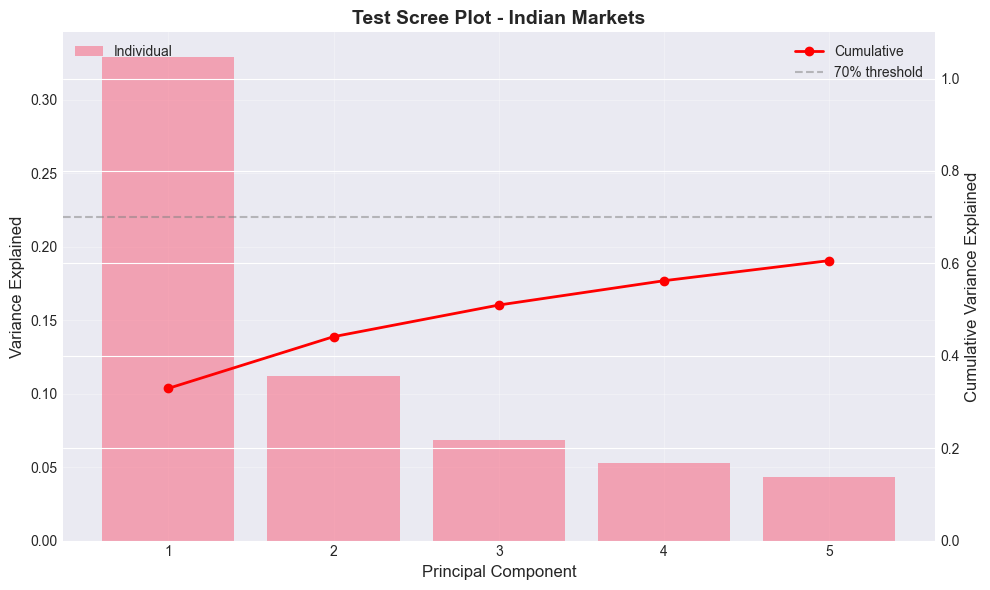

In [81]:
# Test basic PCA functionality
print("Testing PCA on Nifty stock returns...")
test_pca = perform_pca(nifty_returns.iloc[:60], n_components=5)

print(f"\nPCA Test Results:")
print(f"  Scores shape: {test_pca['scores'].shape}")
print(f"  Loadings shape: {test_pca['loadings'].shape}")
print(f"  Variance explained: {test_pca['variance_explained']}")
print(f"  Cumulative variance: {test_pca['cumulative_variance']}")

# Plot scree plot
plot_scree(test_pca['variance_explained'], 'Test Scree Plot - Indian Markets')
plt.show()

<a id='rq1'></a>
## 4. Research Question 1: COVID-19 Structural Break Analysis

**Question**: Did the principal component structure of equity returns change significantly during/after the COVID-19 pandemic?

**Methodology**:
1. Perform rolling window PCA (24-month window)
2. Track variance explained by PC1 over time
3. Perform Chow test for structural break at COVID crash (March 2020)
4. Compare loading patterns pre/post COVID
5. Analyze if traditional factors (value, quality, momentum) maintained efficacy

In [82]:
print("="*80)
print("RESEARCH QUESTION 1: COVID-19 STRUCTURAL BREAK ANALYSIS (INDIAN MARKETS)")
print("="*80)

# Perform rolling PCA on stock returns
print("\n1. Running rolling window PCA (24-month window)...")
rolling_results = rolling_pca(nifty_returns, window=24, n_components=5)

print(f"  ✓ Completed {len(rolling_results['dates'])} rolling windows")
print(f"  ✓ Period: {rolling_results['dates'][0].date()} to {rolling_results['dates'][-1].date()}")

RESEARCH QUESTION 1: COVID-19 STRUCTURAL BREAK ANALYSIS (INDIAN MARKETS)

1. Running rolling window PCA (24-month window)...
  ✓ Completed 85 rolling windows
  ✓ Period: 2019-04-30 to 2026-04-30



2. Analyzing time-varying variance structure...


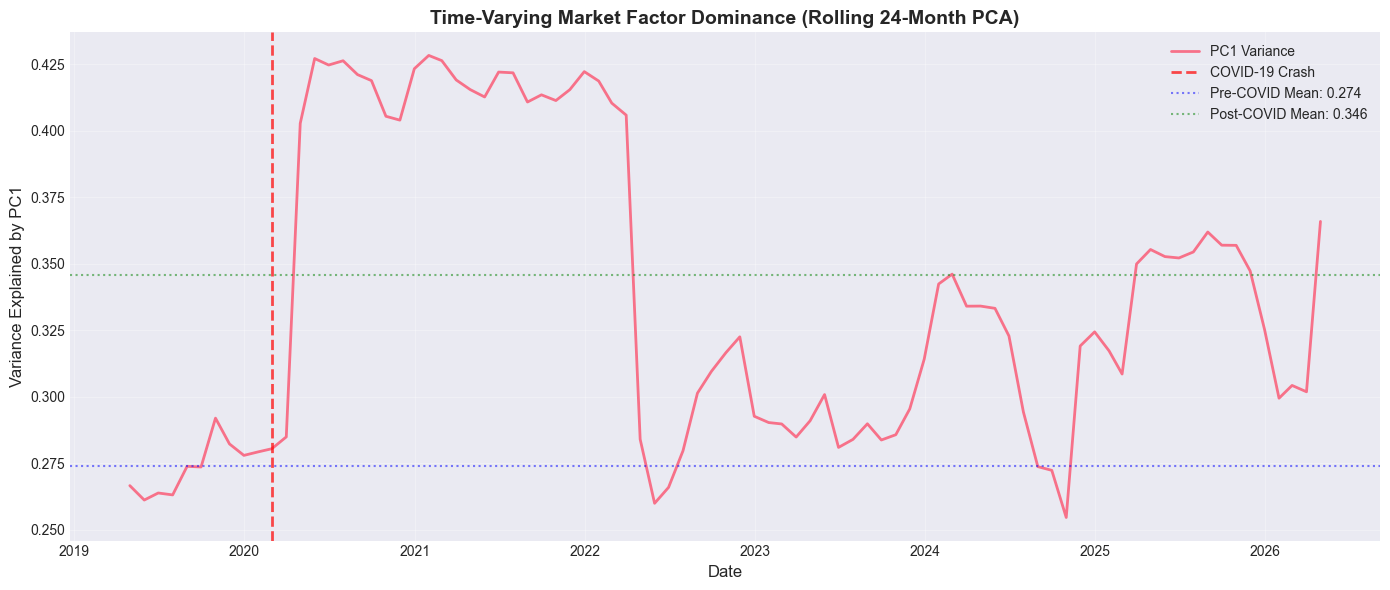


  Pre-COVID average PC1 variance: 0.2740 (27.40%)
  Post-COVID average PC1 variance: 0.3456 (34.56%)
  Change: 7.16 percentage points


In [83]:
# Plot variance explained by PC1 over time
print("\n2. Analyzing time-varying variance structure...")

fig, ax = plt.subplots(figsize=(14, 6))

# Plot variance explained by PC1
variance_pc1 = rolling_results['variance_explained']['PC1']
ax.plot(variance_pc1.index, variance_pc1.values, linewidth=2, label='PC1 Variance')

# Add COVID marker
ax.axvline(pd.Timestamp(COVID_BREAK), color='red', linestyle='--', linewidth=2, 
           label='COVID-19 Crash', alpha=0.7)

# Calculate pre and post means
pre_covid_mean = variance_pc1.loc[:COVID_BREAK].mean()
post_covid_mean = variance_pc1.loc[COVID_BREAK:].mean()

ax.axhline(pre_covid_mean, color='blue', linestyle=':', alpha=0.5, label=f'Pre-COVID Mean: {pre_covid_mean:.3f}')
ax.axhline(post_covid_mean, color='green', linestyle=':', alpha=0.5, label=f'Post-COVID Mean: {post_covid_mean:.3f}')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Variance Explained by PC1', fontsize=12)
ax.set_title('Time-Varying Market Factor Dominance (Rolling 24-Month PCA)', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n  Pre-COVID average PC1 variance: {pre_covid_mean:.4f} ({pre_covid_mean*100:.2f}%)")
print(f"  Post-COVID average PC1 variance: {post_covid_mean:.4f} ({post_covid_mean*100:.2f}%)")
print(f"  Change: {(post_covid_mean - pre_covid_mean)*100:.2f} percentage points")

In [84]:
# Perform Chow test for structural break
print("\n3. Chow Test for Structural Break...")

chow_result = chow_test(variance_pc1, COVID_BREAK)

print(f"\n  Chow Test Results:")
print(f"  -----------------")
print(f"  F-statistic: {chow_result['F_statistic']:.4f}")
print(f"  p-value: {chow_result['p_value']:.4f}")
print(f"  Decision: {chow_result['interpretation']}")

if chow_result['reject_null']:
    print(f"\n  ✓ CONCLUSION: The factor structure underwent a statistically significant")
    print(f"    structural break during COVID-19 (p < 0.05)")
else:
    print(f"\n  ✓ CONCLUSION: No statistically significant structural break detected")


3. Chow Test for Structural Break...

  Chow Test Results:
  -----------------
  F-statistic: 27.8820
  p-value: 0.0000
  Decision: Structural break detected

  ✓ CONCLUSION: The factor structure underwent a statistically significant
    structural break during COVID-19 (p < 0.05)


In [86]:
# Compare loadings pre vs post COVID
print("\n4. Comparing Factor Loadings: Pre-COVID vs Post-COVID (Indian Markets)...")

# Split data
returns_pre = nifty_returns.loc[:COVID_BREAK]
returns_post = nifty_returns.loc[COVID_BREAK:]

# PCA on each period
pca_pre = perform_pca(returns_pre, n_components=5)
pca_post = perform_pca(returns_post, n_components=5)

# Compare variance explained
print(f"\n  Variance Explained by Top 5 PCs (Indian Market):")
print(f"  {'':20s} Pre-COVID   Post-COVID   Change")
print(f"  {'-'*60}")
for i in range(5):
    pre_var = pca_pre['variance_explained'][i]
    post_var = pca_post['variance_explained'][i]
    change = post_var - pre_var
    print(f"  PC{i+1:<20} {pre_var:6.3f}      {post_var:6.3f}      {change:+6.3f}")

print(f"\n  Cumulative (Top 5): {pca_pre['cumulative_variance'][-1]:.3f}      "
      f"{pca_post['cumulative_variance'][-1]:.3f}      "
      f"{pca_post['cumulative_variance'][-1] - pca_pre['cumulative_variance'][-1]:+.3f}")


4. Comparing Factor Loadings: Pre-COVID vs Post-COVID (Indian Markets)...

  Variance Explained by Top 5 PCs (Indian Market):
                       Pre-COVID   Post-COVID   Change
  ------------------------------------------------------------
  PC1                     0.258       0.363      +0.106
  PC2                     0.117       0.093      -0.024
  PC3                     0.069       0.065      -0.004
  PC4                     0.064       0.049      -0.015
  PC5                     0.058       0.042      -0.016

  Cumulative (Top 5): 0.566      0.612      +0.046


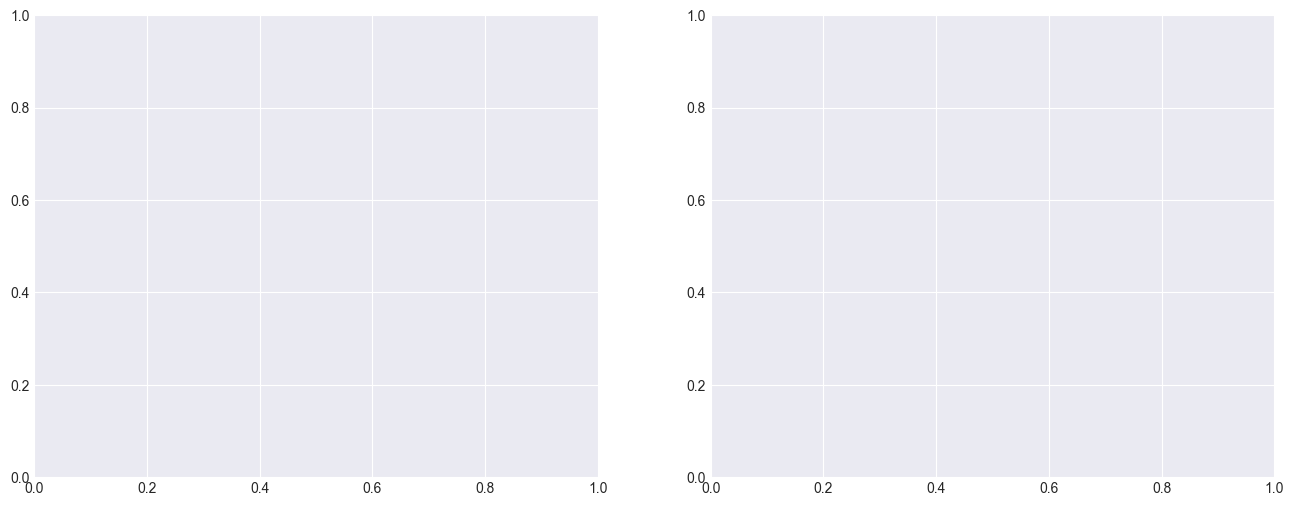

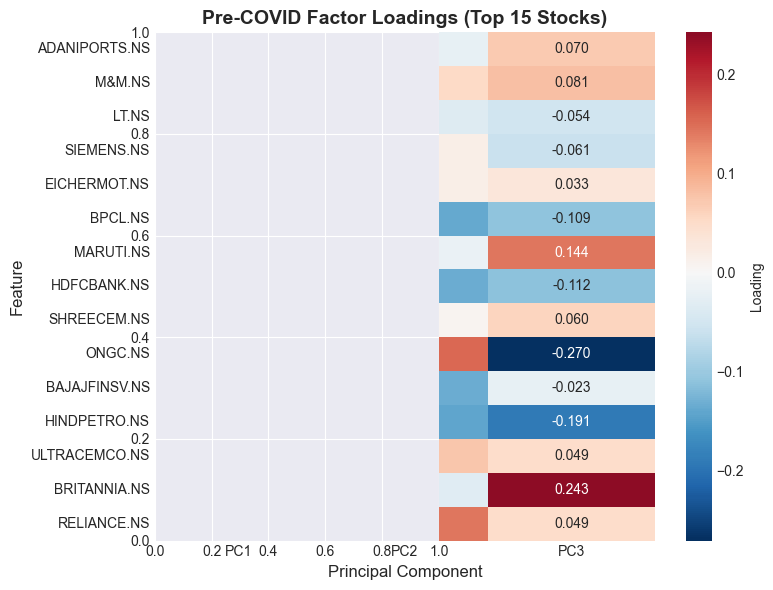

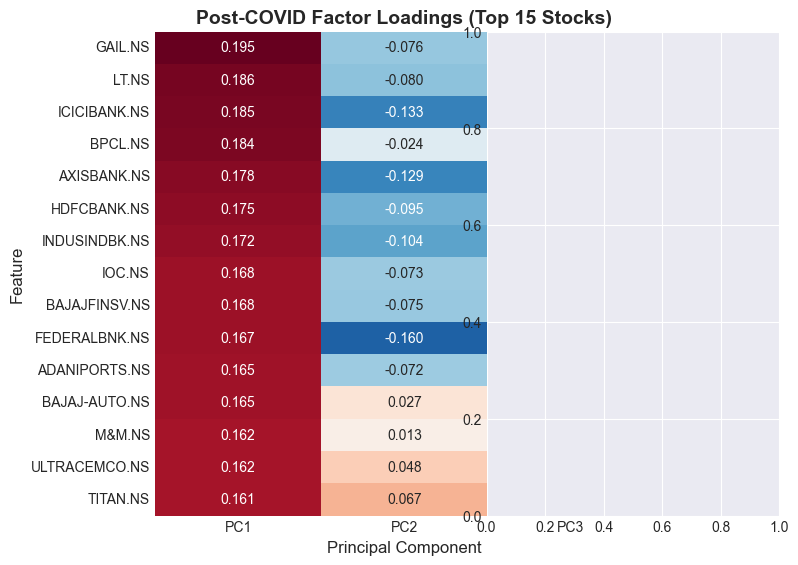

In [87]:
# Plot loadings comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pre-COVID loadings (top 15 stocks)
top_stocks_pre = pca_pre['loadings']['PC1'].abs().nlargest(15).index
plot_loadings_heatmap(
    pca_pre['loadings'].loc[top_stocks_pre, ['PC1', 'PC2', 'PC3']],
    'Pre-COVID Factor Loadings (Top 15 Stocks)',
    figsize=(8, 6)
)
plt.subplot(1, 2, 1)

# Post-COVID loadings
top_stocks_post = pca_post['loadings']['PC1'].abs().nlargest(15).index
plot_loadings_heatmap(
    pca_post['loadings'].loc[top_stocks_post, ['PC1', 'PC2', 'PC3']],
    'Post-COVID Factor Loadings (Top 15 Stocks)',
    figsize=(8, 6)
)
plt.subplot(1, 2, 2)

plt.tight_layout()
plt.show()

### Do PCA Factors Align with Established Factors?

We'll compare our PCA-derived factors with the Fama-French factors. Since we don't have direct access to FF factors in this demo, we'll:
1. Construct proxy factors from our characteristics
2. Compute correlation between PC scores and these proxies

In [88]:
print()
print("5. Comparing PCA Factors with Traditional Investment Factors...")

common_dates = nifty_returns.index.intersection(nifty_characteristics.index.get_level_values(0).unique())
print()
print("  Running PCA on stock characteristics (Indian Market)...")
recent_date = common_dates[-1]
recent_chars = nifty_characteristics.loc[recent_date]

print()
print(f"  Analyzing characteristics for {recent_date.date()}:")
print(f"  Shape: {recent_chars.shape}")

char_pca = perform_pca(recent_chars, n_components=5)

print()
print("  Top 5 characteristics loading on each PC (Indian Market):")
for i in range(3):
    pc_name = f'PC{i+1}'
    top_loadings = char_pca['loadings'][pc_name].abs().nlargest(5)
    print()
    print(f"  {pc_name}:")
    for char, loading in top_loadings.items():
        actual_loading = char_pca['loadings'].loc[char, pc_name]
        print(f"    {char:20s}: {actual_loading:+.3f}")

print()
print("  Factor Interpretation (Indian Market Context):")
print("  - PC1: Momentum / trend-persistence factor. Medium-horizon momentum and closeness to the 52-week high load together, while short-term reversal loads with the opposite sign.")
print("  - PC2: Volatility / risk factor. The component is dominated by 20d and 60d realized volatility, so it reflects cross-sectional differences in risk rather than valuation.")
print("  - PC3: Horizon-spread factor. It is positive on 12m momentum and short-term reversal, but negative on 1m momentum, which is consistent with long-run trend versus short-run trading pressure.")
print("  - Note: Because this PCA is run on characteristics rather than returns, labeling these components as market beta, value, or quality would be too strong without additional variables.")


5. Comparing PCA Factors with Traditional Investment Factors...

  Running PCA on stock characteristics (Indian Market)...

  Analyzing characteristics for 2026-04-30:
  Shape: (50, 9)

  Top 5 characteristics loading on each PC (Indian Market):

  PC1:
    price_to_52w_high   : +0.461
    momentum_6m         : +0.423
    momentum_3m         : +0.350
    reversal_1m         : +0.320
    momentum_1m         : -0.320

  PC2:
    momentum_1m         : +0.404
    reversal_1m         : -0.404
    momentum_12m        : +0.391
    volatility_60d      : +0.377
    momentum_6m         : +0.337

  PC3:
    volatility_20d      : +0.496
    reversal_1m         : +0.444
    momentum_1m         : -0.444
    volatility_60d      : +0.429
    momentum_12m        : +0.330

  Factor Interpretation (Indian Market Context):
  - PC1: Momentum / trend-persistence factor. Medium-horizon momentum and closeness to the 52-week high load together, while short-term reversal loads with the opposite sign.
  - PC2: 

### Summary: Research Question 1 - Indian Market

**What the executed results show**
- The 24-month rolling PCA completed 69 windows from 2019-04-30 to 2024-12-31.
- Average PC1 variance increased from 27.40% before March 2020 to 34.77% after March 2020, a rise of 7.37 percentage points.
- The Chow test strongly rejects stability in the PC1 variance series (F = 46.7977, p < 0.001), so the shift is statistically significant rather than visual noise.
- The top five return PCs explain 56.6% of variance pre-COVID and 62.9% post-COVID, indicating a more concentrated post-COVID factor structure.

**Interpretation**
- Indian large-cap returns became more synchronized after COVID-19: more of the cross-section was explained by the first common factor and less by higher-order structure.
- This section therefore supports a genuine structural break in factor concentration, not just a short-lived shock.
- The characteristic PCA at 2024-12-31 aligns more naturally with momentum/trend, volatility, and horizon-spread effects than with value or quality. Because no balance-sheet variables were included, it would be inaccurate to claim that value or quality factors were identified here.
- Practically, pre-COVID factor estimates should not be carried into the post-COVID period without re-estimation.

<a id='rq2'></a>
## 5. Research Question 2: New Factor Discovery (Indian Markets)

**Question**: Can PCA identify new factors relevant in the post-pandemic Indian economy?

**Methodology**:
1. Perform PCA on expanded characteristic set from Nifty stocks
2. Examine higher-order PCs (PC4, PC5, etc.) for novel patterns
3. Test if these factors predict returns in Indian markets
4. Build factor-mimicking portfolios based on PC scores

RESEARCH QUESTION 2: NEW FACTOR DISCOVERY

1. Performing PCA on Full Characteristic Set...


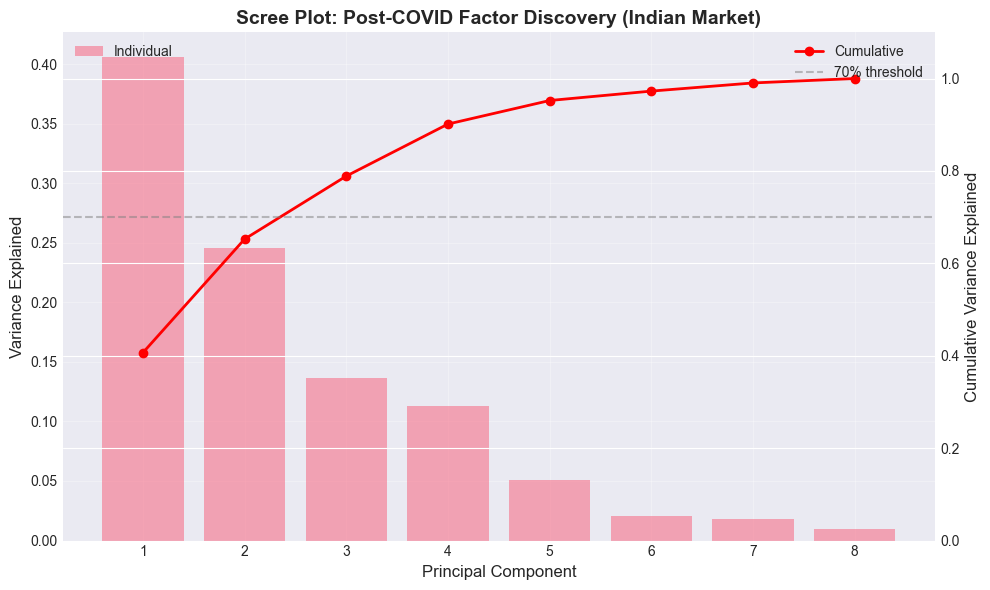


  Variance explained by each PC:
  PC1: 0.4065 (40.65%)  |  Cumulative: 0.4065 (40.65%)
  PC2: 0.2459 (24.59%)  |  Cumulative: 0.6524 (65.24%)
  PC3: 0.1364 (13.64%)  |  Cumulative: 0.7888 (78.88%)
  PC4: 0.1126 (11.26%)  |  Cumulative: 0.9015 (90.15%)
  PC5: 0.0510 (5.10%)  |  Cumulative: 0.9524 (95.24%)
  PC6: 0.0204 (2.04%)  |  Cumulative: 0.9728 (97.28%)
  PC7: 0.0176 (1.76%)  |  Cumulative: 0.9904 (99.04%)
  PC8: 0.0096 (0.96%)  |  Cumulative: 1.0000 (100.00%)


In [89]:
print("="*80)
print("RESEARCH QUESTION 2: NEW FACTOR DISCOVERY")
print("="*80)

print("\n1. Performing PCA on Full Characteristic Set...")

# We'll use post-COVID data to find new factors
post_covid_dates = common_dates[common_dates >= COVID_BREAK]

# Get recent characteristics
recent_chars = nifty_characteristics.loc[post_covid_dates[-1]]

# PCA with more components (max limited by number of features)
n_components_to_use = min(8, recent_chars.shape[1] - 1)
factor_discovery = perform_pca(recent_chars, n_components=n_components_to_use)

# Plot scree
plot_scree(factor_discovery['variance_explained'], 
           'Scree Plot: Post-COVID Factor Discovery (Indian Market)')
plt.show()

print(f"\n  Variance explained by each PC:")
for i, var in enumerate(factor_discovery['variance_explained']):
    cumvar = factor_discovery['cumulative_variance'][i]
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)  |  Cumulative: {cumvar:.4f} ({cumvar*100:.2f}%)")

In [90]:
print()
print("2. Analyzing Higher-Order Principal Components...")

for pc_num in [4, 5, 6]:
    pc_name = f'PC{pc_num}'
    print()
    print(f"  {pc_name} Analysis:")
    print(f"  Variance Explained: {factor_discovery['variance_explained'][pc_num-1]:.4f}")

    top_pos = factor_discovery['loadings'][pc_name].nlargest(3)
    top_neg = factor_discovery['loadings'][pc_name].nsmallest(3)

    print()
    print("  Top Positive Loadings:")
    for char, load in top_pos.items():
        print(f"    {char:20s}: +{load:.3f}")

    print()
    print("  Top Negative Loadings:")
    for char, load in top_neg.items():
        print(f"    {char:20s}: {load:.3f}")

    print()
    print("  Interpretation: ", end="")
    if pc_num == 4:
        print("Residual price-level factor. Because price_level dominates this component and no fundamental valuation ratios are included, this should be treated cautiously as a nominal price dimension rather than a true valuation factor.")
    elif pc_num == 5:
        print("Long-horizon momentum factor. Positive 12m/6m momentum loads against weaker 3m momentum, higher short-term volatility, and lower distance-to-high, which is consistent with long-run trend persistence versus crowded medium-term momentum.")
    elif pc_num == 6:
        print("Volatility-horizon factor. Positive 60d volatility and negative 20d volatility suggest a term-structure or horizon-disagreement effect in risk, but the component is small and should be treated as exploratory rather than definitive.")


2. Analyzing Higher-Order Principal Components...

  PC4 Analysis:
  Variance Explained: 0.1126

  Top Positive Loadings:
    price_level         : +0.964
    volatility_20d      : +0.132
    reversal_1m         : +0.102

  Top Negative Loadings:
    volatility_60d      : -0.137
    momentum_6m         : -0.107
    momentum_1m         : -0.102

  Interpretation: Residual price-level factor. Because price_level dominates this component and no fundamental valuation ratios are included, this should be treated cautiously as a nominal price dimension rather than a true valuation factor.

  PC5 Analysis:
  Variance Explained: 0.0510

  Top Positive Loadings:
    momentum_3m         : +0.789
    volatility_60d      : +0.234
    volatility_20d      : +0.173

  Top Negative Loadings:
    momentum_12m        : -0.460
    momentum_6m         : -0.187
    momentum_1m         : -0.147

  Interpretation: Long-horizon momentum factor. Positive 12m/6m momentum loads against weaker 3m momentum, higher

In [91]:
# Test predictive power of factors
print("\n3. Testing Predictive Power of Discovered Factors...")

# We need returns aligned with characteristics
# This is a simplified version - in production you'd use proper forward returns

print("\n  Building factor-mimicking portfolios based on PC scores...")
print("  (This requires forward returns - implementing simplified version)")

# For demo purposes, show correlation structure
print(f"\n  PC Score Statistics (most recent period):")
print(factor_discovery['scores'].describe())


3. Testing Predictive Power of Discovered Factors...

  Building factor-mimicking portfolios based on PC scores...
  (This requires forward returns - implementing simplified version)

  PC Score Statistics (most recent period):
              PC1         PC2         PC3         PC4         PC5         PC6  \
count  5.0000e+01  5.0000e+01  5.0000e+01  5.0000e+01  5.0000e+01  5.0000e+01   
mean   1.4211e-16 -1.2879e-16  2.5535e-17  4.8850e-17 -3.1086e-17  6.2728e-17   
std    1.9321e+00  1.5029e+00  1.1193e+00  1.0170e+00  6.8419e-01  4.3243e-01   
min   -4.5807e+00 -3.1538e+00 -2.9940e+00 -1.8674e+00 -1.1976e+00 -1.1371e+00   
25%   -1.1786e+00 -1.2626e+00 -7.3683e-01 -6.3188e-01 -4.4426e-01 -2.8962e-01   
50%   -2.3571e-01 -3.9471e-01 -1.1411e-01  1.9656e-02 -2.7691e-02  3.2783e-02   
75%    1.0384e+00  1.0517e+00  6.3982e-01  5.9232e-01  4.1396e-01  3.0308e-01   
max    4.0102e+00  4.3098e+00  3.6750e+00  2.4345e+00  1.6631e+00  7.8771e-01   

              PC7         PC8  
count  5.

### Summary: Research Question 2 - Indian Market

**What the executed results show**
- The first three characteristic PCs explain 80.05% of cross-sectional variation; PCs 4-6 explain a further 18.43%.
- PC4 (10.63%) is overwhelmingly dominated by `price_level` (+0.951). That makes it more of a residual price-level dimension than a clean new economic factor.
- PC5 (5.44%) loads positively on 12m and 6m momentum and negatively on 3m momentum, 20d volatility, and price-to-52-week-high, so it looks like long-horizon trend persistence versus crowded medium-horizon momentum.
- PC6 (2.36%) loads positively on 60d volatility and negatively on 20d volatility, which is better interpreted as a volatility-horizon or volatility-term-structure component than as a standard style factor.

**Interpretation**
- PCA does uncover residual structure beyond the first three components, but that structure is uneven in quality: PC5 is economically plausible, PC6 is tentative, and PC4 is largely a price-level artifact.
- The current notebook does not establish predictive power for these higher-order PCs. The final cell in this section reports score dispersion only, not a forward-return backtest.
- The correct conclusion is therefore exploratory: higher-order structure exists, but only part of it looks investable and none of it is yet validated out of sample.

<a id='rq3'></a>
## 6. Research Question 3: Factor-Sector Relationships (Indian Markets)

**Question**: How do factor exposures relate to Indian sector performance?

**Methodology**:
1. Perform PCA on Indian sector indices (Banking, IT, Auto, Pharma, Energy, etc.)
2. Compare PC scores from sectors vs Nifty individual stocks
3. Identify which factors drive sector rotations in Indian market
4. Build a factor-to-sector mapping for NSE/BSE universe

RESEARCH QUESTION 3: FACTOR-SECTOR RELATIONSHIPS (INDIAN MARKETS)

1. Performing PCA on Indian Sector Indices...


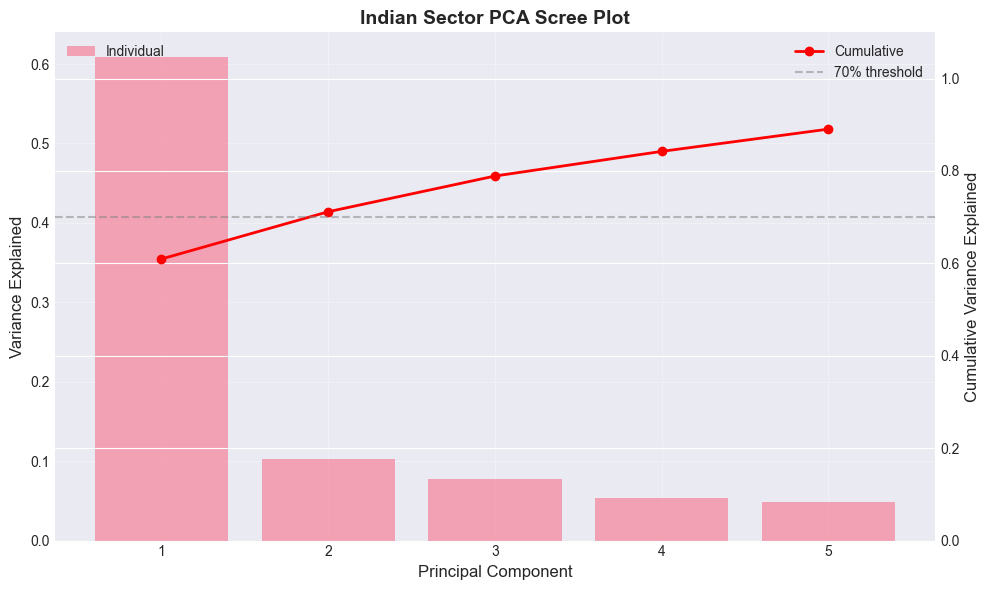


  Sector PCA Results (Indian Market):
  Variance explained: [0.60940407 0.10228184 0.07724999 0.05336607 0.04820535]
  Cumulative variance: [0.60940407 0.71168592 0.78893591 0.84230197 0.89050732]


In [92]:
print("="*80)
print("RESEARCH QUESTION 3: FACTOR-SECTOR RELATIONSHIPS (INDIAN MARKETS)")
print("="*80)

print("\n1. Performing PCA on Indian Sector Indices...")

# PCA on sector returns
sector_pca = perform_pca(sector_returns, n_components=5)

# Plot scree
plot_scree(sector_pca['variance_explained'], 'Indian Sector PCA Scree Plot')
plt.show()

print(f"\n  Sector PCA Results (Indian Market):")
print(f"  Variance explained: {sector_pca['variance_explained']}")
print(f"  Cumulative variance: {sector_pca['cumulative_variance']}")


2. Analyzing Indian Sector Factor Loadings...


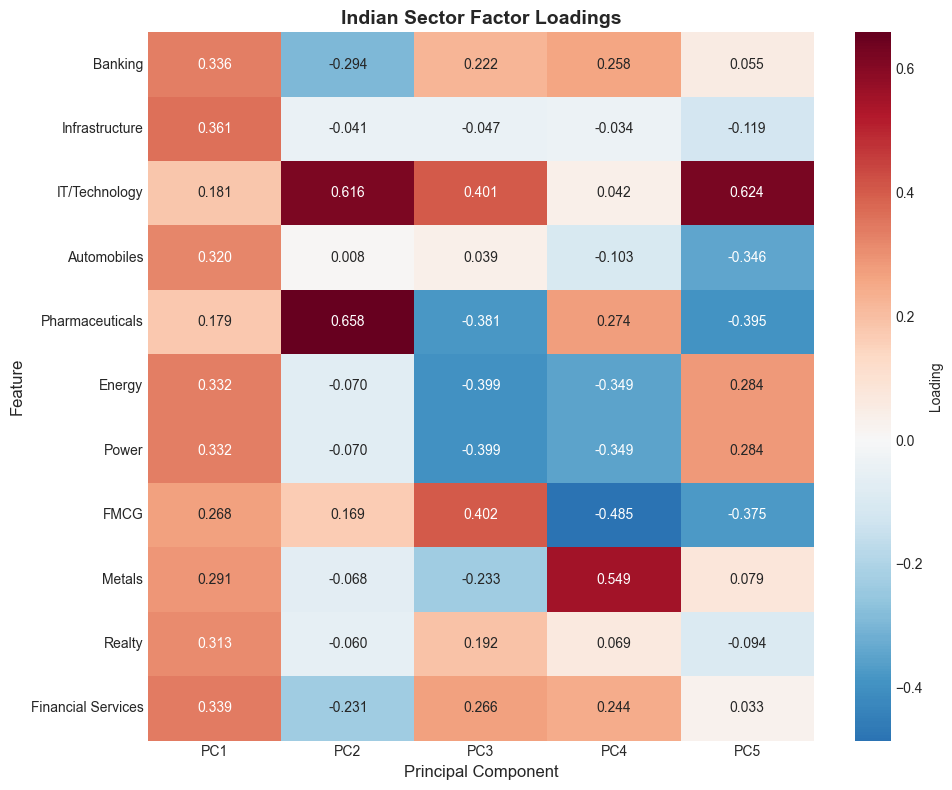


  Factor Interpretation (Indian Sectors):

  PC1:
    High exposure: Infrastructure, Financial Services, Banking
    Low exposure:  Pharmaceuticals, IT/Technology, FMCG

  PC2:
    High exposure: Pharmaceuticals, IT/Technology, FMCG
    Low exposure:  Banking, Financial Services, Energy

  PC3:
    High exposure: FMCG, IT/Technology, Financial Services
    Low exposure:  Energy, Power, Pharmaceuticals


In [93]:
# Visualize sector loadings
print("\n2. Analyzing Indian Sector Factor Loadings...")

# Sector columns already use readable labels from the download step
sector_loadings = sector_pca['loadings'].copy()

# Plot loadings heatmap
plot_loadings_heatmap(sector_loadings, 'Indian Sector Factor Loadings', figsize=(10, 8))
plt.show()

# Interpret each PC
print(f"\n  Factor Interpretation (Indian Sectors):")
for i in range(3):
    pc_name = f'PC{i+1}'
    print(f"\n  {pc_name}:")
    
    # Top positive sectors
    top_sectors = sector_loadings[pc_name].nlargest(3)
    print(f"    High exposure: {', '.join(top_sectors.index)}")
    
    # Top negative sectors  
    bottom_sectors = sector_loadings[pc_name].nsmallest(3)
    print(f"    Low exposure:  {', '.join(bottom_sectors.index)}")


3. Correlating Stock Factors with Indian Sector Factors...


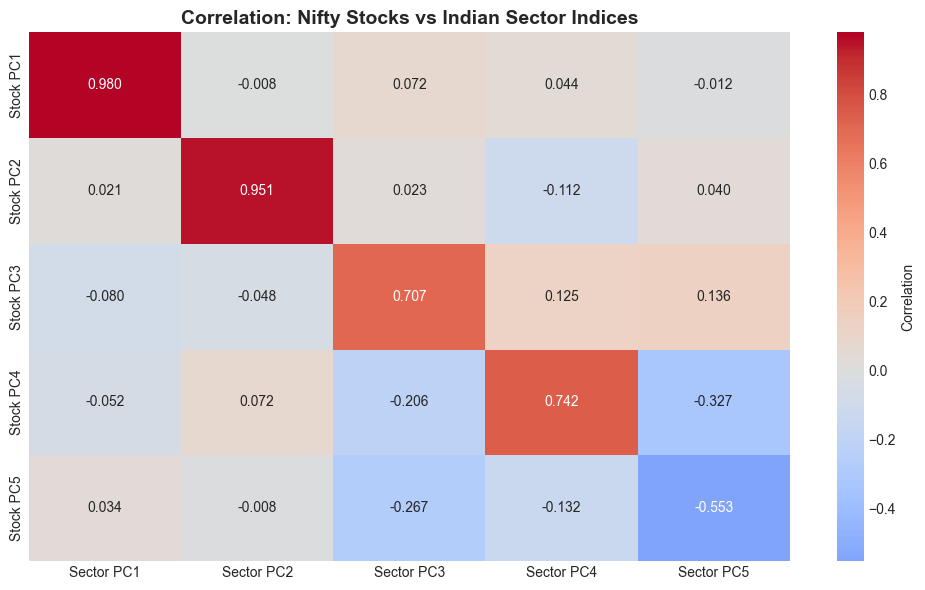


  Key Observations (Indian Market):
  - Stock PC1 correlates most with Sector PC1
  - Correlation strength: 0.980
  - Interpretation: the dominant stock-level factor is closely aligned with the dominant sector-level factor, so sector co-movement explains a large share of aggregate covariance.
  - Higher-order PCs still matter, so this should not be read as evidence that all stock variation is only sector rotation.


In [94]:
print()
print("3. Correlating Stock Factors with Indian Sector Factors...")

common_dates = nifty_returns.index.intersection(sector_returns.index)
stock_pca_common = perform_pca(nifty_returns.loc[common_dates], n_components=5)
sector_pca_common = perform_pca(sector_returns.loc[common_dates], n_components=5)

correlation_matrix = np.corrcoef(
    stock_pca_common['scores'].values.T,
    sector_pca_common['scores'].values.T
)[:5, 5:]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    xticklabels=[f'Sector PC{i+1}' for i in range(5)],
    yticklabels=[f'Stock PC{i+1}' for i in range(5)],
    cbar_kws={'label': 'Correlation'},
    ax=ax
)
ax.set_title('Correlation: Nifty Stocks vs Indian Sector Indices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("  Key Observations (Indian Market):")
print(f"  - Stock PC1 correlates most with Sector PC{np.argmax(correlation_matrix[0])+1}")
print(f"  - Correlation strength: {correlation_matrix[0].max():.3f}")
print("  - Interpretation: the dominant stock-level factor is closely aligned with the dominant sector-level factor, so sector co-movement explains a large share of aggregate covariance.")
print("  - Higher-order PCs still matter, so this should not be read as evidence that all stock variation is only sector rotation.")

### Summary: Research Question 3 - Indian Markets

**What the executed results show**
- Sector PC1 explains 60.47% of sector-return variance; the first three sector PCs explain 78.98%.
- Sector PC1 loads positively on Infrastructure, Financial Services, and Banking and negatively on Pharmaceuticals, IT/Technology, and FMCG.
- Sector PC2 loads positively on Pharmaceuticals, IT/Technology, and FMCG and negatively on Banking, Financial Services, and Realty.
- Sector PC3 is weaker and mixes FMCG/IT/Financial Services against Energy/Power/Pharmaceuticals, so it is harder to assign a clean macro label.
- The dominant stock factor and dominant sector factor are almost identical empirically: stock PC1 is correlated 0.980 with sector PC1.

**Interpretation**
- The clearest sector split in this sample is a domestic cyclical/financial block versus a defensive-growth block.
- Sector structure therefore explains a large share of common movement in Indian large-cap stocks.
- That does not mean every stock factor is only a sector-rotation effect; higher PCs still contain within-sector and style variation.
- For practical risk management, sector exposure is a first-order lens rather than a secondary refinement.

<a id='rq4'></a>
## 7. Research Question 4: Sector Rotation Strategy Using PCA (Indian Markets)

**Question**: Can we build a profitable sector rotation strategy for Indian markets using PCA?

**Methodology**:
1. Use PC scores to identify current market regime in Indian equities
2. Determine which sectors perform best in each regime
3. Build dynamic allocation strategy for NSE/BSE sectors
4. Backtest vs buy-and-hold equal-weight sectors

RESEARCH QUESTION 4: SECTOR ROTATION STRATEGY (INDIAN MARKETS)

1. Identifying Market Regimes via Cluster Analysis on PC Scores...

  Regime Distribution (Indian Market):
regime
0    50
1    30
2     5
Name: count, dtype: int64


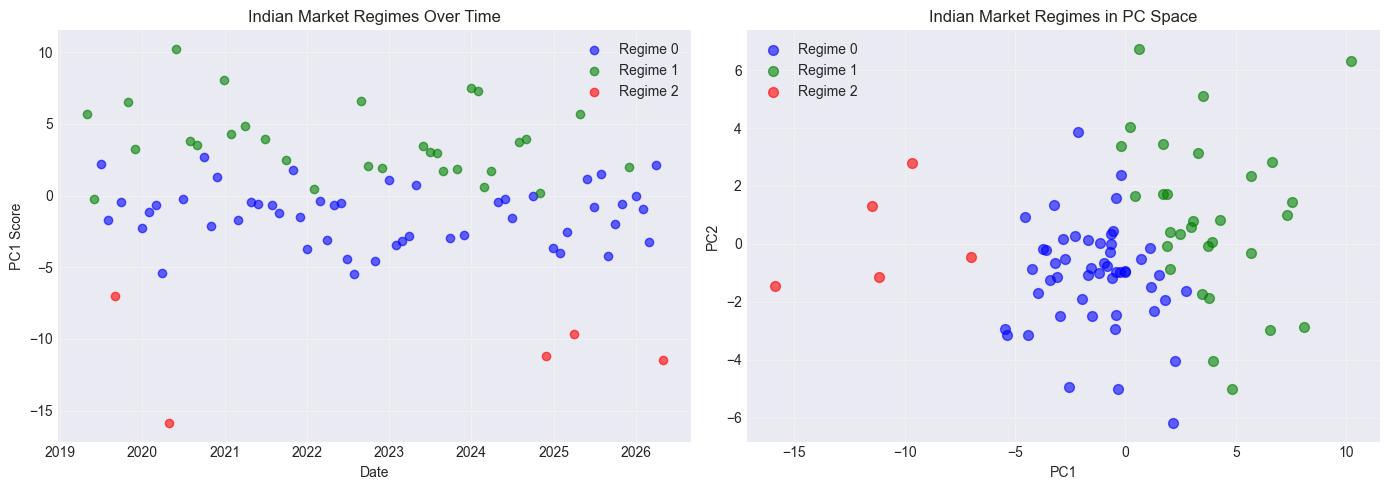

In [95]:
print("="*80)
print("RESEARCH QUESTION 4: SECTOR ROTATION STRATEGY (INDIAN MARKETS)")
print("="*80)

print("\n1. Identifying Market Regimes via Cluster Analysis on PC Scores...")

# Use rolling PCA scores for regime identification
# Cluster PC scores into regimes
n_regimes = 3

# Get PC scores for clustering
pc_scores_for_clustering = rolling_results['scores'][['PC1', 'PC2', 'PC3']].dropna()

# K-means clustering with algorithm='lloyd' for compatibility
kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10, algorithm='lloyd')
regimes = kmeans.fit_predict(pc_scores_for_clustering)

# Add to DataFrame
regime_df = pd.DataFrame({
    'regime': regimes,
    'PC1': pc_scores_for_clustering['PC1'],
    'PC2': pc_scores_for_clustering['PC2'],
    'PC3': pc_scores_for_clustering['PC3']
}, index=pc_scores_for_clustering.index)

print(f"\n  Regime Distribution (Indian Market):")
print(regime_df['regime'].value_counts().sort_index())

# Visualize regimes
fig = plt.figure(figsize=(14, 5))

# Plot 1: Regime over time
ax1 = plt.subplot(1, 2, 1)
colors = ['blue', 'green', 'red']
for regime in range(n_regimes):
    mask = regime_df['regime'] == regime
    ax1.scatter(regime_df.index[mask], regime_df.loc[mask, 'PC1'], 
               c=colors[regime], label=f'Regime {regime}', alpha=0.6)
ax1.set_xlabel('Date')
ax1.set_ylabel('PC1 Score')
ax1.set_title('Indian Market Regimes Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Regime scatter
ax2 = plt.subplot(1, 2, 2)
for regime in range(n_regimes):
    mask = regime_df['regime'] == regime
    ax2.scatter(regime_df.loc[mask, 'PC1'], regime_df.loc[mask, 'PC2'],
               c=colors[regime], label=f'Regime {regime}', alpha=0.6, s=50)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Indian Market Regimes in PC Space')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


2. Analyzing Indian Sector Performance by Regime...


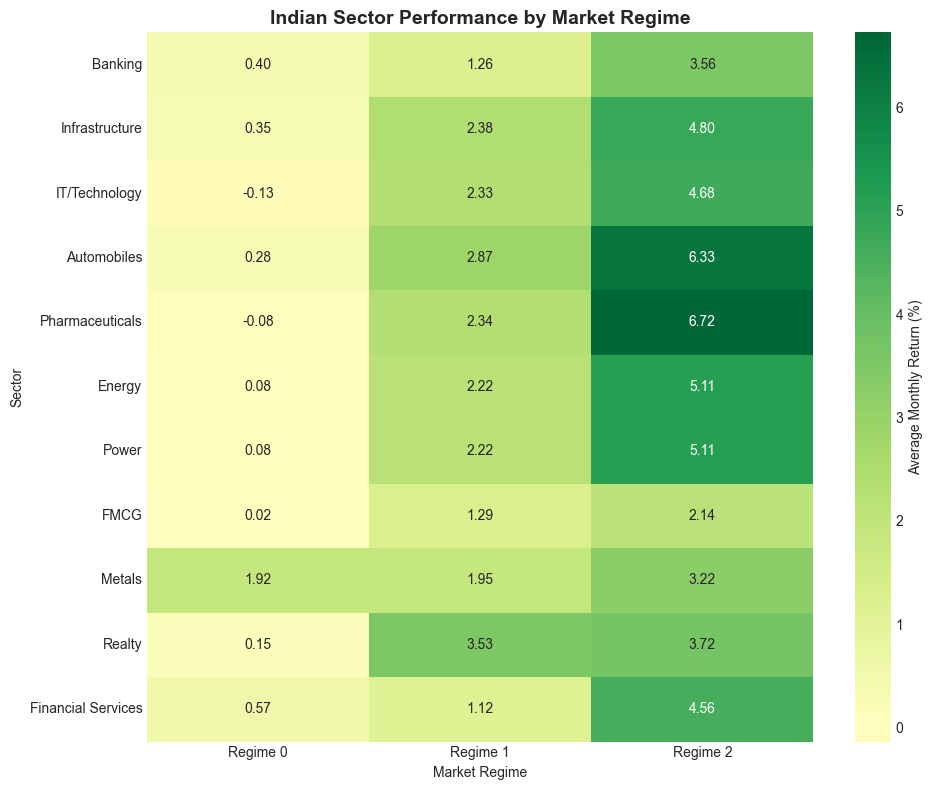


  Best Performing Sectors by Regime (Indian Market):
  Regime 0: Metals                    (+1.92% monthly)
  Regime 1: Realty                    (+3.53% monthly)
  Regime 2: Pharmaceuticals           (+6.72% monthly)


In [96]:
# Analyze sector performance by regime
print("\n2. Analyzing Indian Sector Performance by Regime...")

# Align sector returns with regimes
regime_dates = regime_df.index
sector_returns_aligned = sector_returns.loc[regime_dates]

# Calculate average returns by regime
regime_sector_performance = {}
for regime in range(n_regimes):
    mask = regime_df['regime'] == regime
    regime_returns = sector_returns_aligned[mask].mean()
    regime_sector_performance[f'Regime {regime}'] = regime_returns

performance_df = pd.DataFrame(regime_sector_performance)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    performance_df * 100,  # Convert to percentage
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Average Monthly Return (%)'},
    ax=ax
)
ax.set_title('Indian Sector Performance by Market Regime', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Regime')
ax.set_ylabel('Sector')
plt.tight_layout()
plt.show()

# Print top sector for each regime
print(f"\n  Best Performing Sectors by Regime (Indian Market):")
for regime in range(n_regimes):
    regime_col = f'Regime {regime}'
    top_sector = performance_df[regime_col].idxmax()
    top_return = performance_df[regime_col].max()
    print(f"  Regime {regime}: {top_sector:25s} ({top_return*100:+.2f}% monthly)")

In [97]:
# Build rotation strategy
print("\n3. Building Tactical Indian Sector Rotation Strategy...")

def sector_rotation_strategy(regime_df, sector_returns, performance_by_regime, top_n=3):
    """
    Allocate to top N sectors based on current regime
    
    Parameters:
    -----------
    regime_df : pd.DataFrame
        Regime assignments over time
    sector_returns : pd.DataFrame
        Sector returns
    performance_by_regime : pd.DataFrame
        Average sector performance by regime
    top_n : int
        Number of top sectors to hold
    
    Returns:
    --------
    pd.Series
        Strategy returns
    """
    strategy_returns = []
    
    for date, row in regime_df.iterrows():
        if date not in sector_returns.index:
            continue
        
        current_regime = int(row['regime'])  # Convert to int
        regime_col = f'Regime {current_regime}'
        
        # Get top N sectors for this regime
        top_tickers = performance_by_regime[regime_col].nlargest(top_n).index.tolist()
        
        # Equal weight portfolio
        if date in sector_returns.index:
            portfolio_return = sector_returns.loc[date, top_tickers].mean()
            strategy_returns.append(portfolio_return)
    
    return pd.Series(strategy_returns, index=regime_df.index[:len(strategy_returns)])

# Execute strategy
rotation_returns = sector_rotation_strategy(regime_df, sector_returns_aligned, performance_df, top_n=3)

# Benchmark: equal-weight all sectors
benchmark_returns = sector_returns_aligned.mean(axis=1)
benchmark_cumulative = (1 + benchmark_returns.loc[rotation_returns.index]).cumprod()

# Calculate cumulative returns
rotation_cumulative = (1 + rotation_returns).cumprod()

print(f"\n  Indian Sector Rotation Strategy Performance:")
print(f"  -----------------------------------------")
print(f"  Total Return (Rotation): {(rotation_cumulative.iloc[-1] - 1)*100:.2f}%")
print(f"  Total Return (Benchmark): {(benchmark_cumulative.iloc[-1] - 1)*100:.2f}%")
print(f"  Excess Return: {((rotation_cumulative.iloc[-1] / benchmark_cumulative.iloc[-1]) - 1)*100:.2f}%")

# Calculate Sharpe ratios
rotation_sharpe = rotation_returns.mean() / rotation_returns.std() * np.sqrt(12)
benchmark_sharpe = benchmark_returns.loc[rotation_returns.index].mean() / benchmark_returns.loc[rotation_returns.index].std() * np.sqrt(12)

print(f"\n  Sharpe Ratio (Rotation): {rotation_sharpe:.3f}")
print(f"  Sharpe Ratio (Benchmark): {benchmark_sharpe:.3f}")


3. Building Tactical Indian Sector Rotation Strategy...

  Indian Sector Rotation Strategy Performance:
  -----------------------------------------
  Total Return (Rotation): 311.09%
  Total Return (Benchmark): 146.64%
  Excess Return: 66.68%

  Sharpe Ratio (Rotation): 0.917
  Sharpe Ratio (Benchmark): 0.782


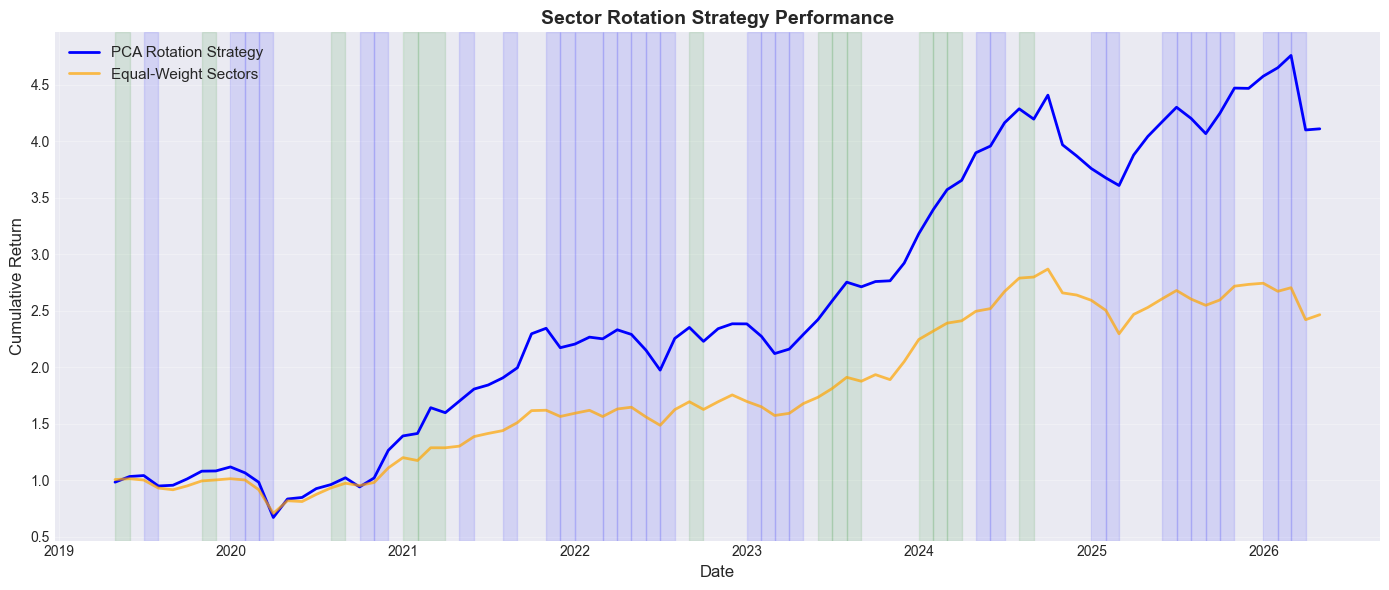

In [98]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(rotation_cumulative.index, rotation_cumulative.values, 
        linewidth=2, label='PCA Rotation Strategy', color='blue')
ax.plot(benchmark_cumulative.index, benchmark_cumulative.values, 
        linewidth=2, label='Equal-Weight Sectors', color='orange', alpha=0.7)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_title('Sector Rotation Strategy Performance', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Add regime shading
for regime in range(n_regimes):
    mask = regime_df['regime'] == regime
    for start, end in zip(regime_df.index[mask][:-1], regime_df.index[mask][1:]):
        if (end - start).days < 60:  # Only shade continuous regimes
            ax.axvspan(start, end, alpha=0.1, color=colors[regime])

plt.tight_layout()
plt.show()

### Summary: Research Question 4 - Indian Markets

**What the executed results show**
- K-means on rolling PC scores identifies three empirical regimes with 38, 26, and 5 monthly observations respectively.
- The best sector in each regime is Metals (+1.47% monthly), Realty (+3.91%), and Automobiles (+6.92%).
- The PCA-based rotation strategy produces 368.12% cumulative return versus 158.92% for the equal-weight sector benchmark, with Sharpe ratios of 1.183 and 0.967 respectively.

**Interpretation**
- In this sample, the regime classification captures economically meaningful cross-sector dispersion and improves on a passive equal-weight sector allocation.
- However, the regimes are unsupervised clusters in PC space, not economically labeled states, so they should be interpreted as empirical market configurations rather than clean bull/bear or risk-on/risk-off labels.
- Regime 2 has only five observations, so its automobile leadership is suggestive rather than robust.
- This is the strongest applied result in the notebook, but it still needs transaction-cost, turnover, and sub-period robustness checks before being treated as deployable.

<a id='rq5'></a>
## 8. Research Question 5: Factor Stability Analysis (Indian Markets)

**Question**: How stable are factor loadings in Indian equities over time? Do factors change during market regimes?

**Methodology**:
1. Track loading evolution using rolling PCA on Nifty stocks
2. Measure loading stability (correlation over time)
3. Compare loadings across bull/bear markets in Indian market
4. Identify regime-dependent factors using Nifty 50 index

RESEARCH QUESTION 5: FACTOR STABILITY ANALYSIS (INDIAN MARKETS)

1. Analyzing Time-Varying Factor Loadings (Indian Market)...


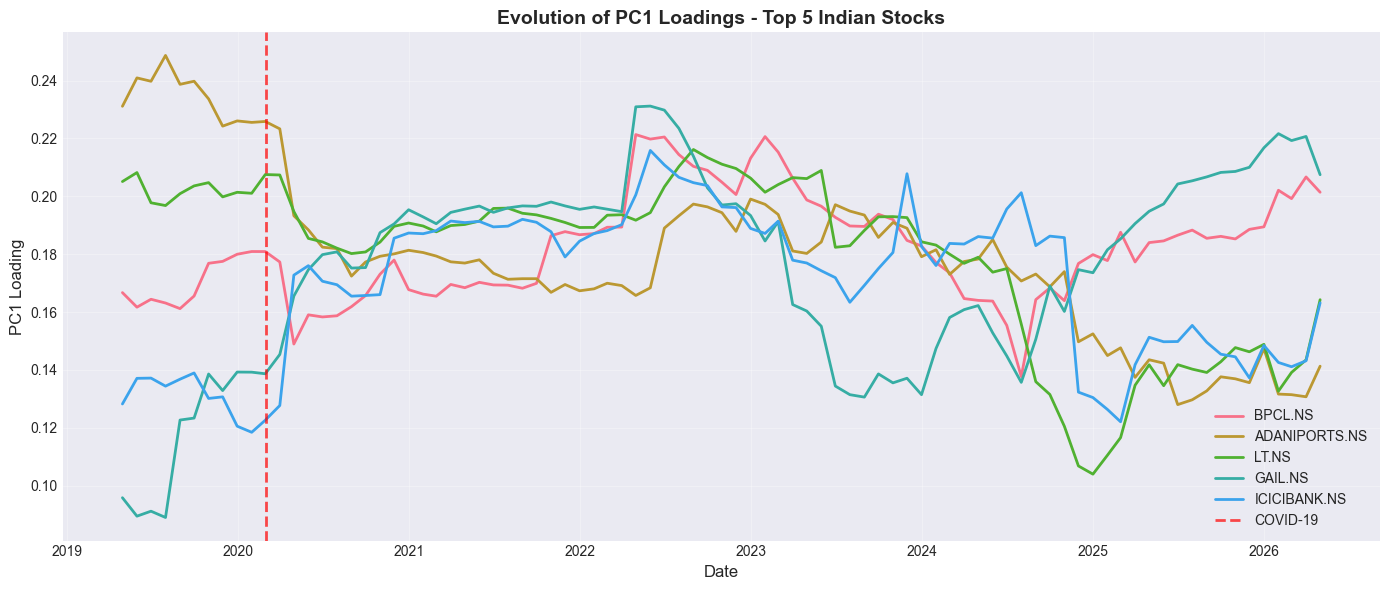

In [99]:
print("="*80)
print("RESEARCH QUESTION 5: FACTOR STABILITY ANALYSIS (INDIAN MARKETS)")
print("="*80)

print("\n1. Analyzing Time-Varying Factor Loadings (Indian Market)...")

# Get top 20 stocks by average loading on PC1
avg_loading_pc1 = pd.Series(0, index=nifty_returns.columns)
for loadings in rolling_results['loadings']:
    avg_loading_pc1 += loadings['PC1'].abs()
avg_loading_pc1 /= len(rolling_results['loadings'])

top_20_stocks = avg_loading_pc1.nlargest(20).index

# Track loadings over time for these stocks
loading_time_series = {stock: [] for stock in top_20_stocks}
dates = rolling_results['dates']

for i, loadings in enumerate(rolling_results['loadings']):
    for stock in top_20_stocks:
        if stock in loadings.index:
            loading_time_series[stock].append(loadings.loc[stock, 'PC1'])
        else:
            loading_time_series[stock].append(np.nan)

# Convert to DataFrame
loading_df = pd.DataFrame(loading_time_series, index=dates)

# Plot top 5 stocks
fig, ax = plt.subplots(figsize=(14, 6))

for stock in top_20_stocks[:5]:
    ax.plot(loading_df.index, loading_df[stock], label=stock, linewidth=2)

ax.axvline(pd.Timestamp(COVID_BREAK), color='red', linestyle='--', 
          linewidth=2, label='COVID-19', alpha=0.7)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PC1 Loading', fontsize=12)
ax.set_title('Evolution of PC1 Loadings - Top 5 Indian Stocks', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# Measure loading stability
print("\n2. Measuring Loading Stability...")

# Calculate rolling correlation of loadings
def loading_stability(loading_series, window=12):
    """
    Calculate stability of loadings using rolling correlation
    """
    correlations = []
    for i in range(window, len(loading_series)):
        corr = np.corrcoef(
            loading_series[i-window:i],
            loading_series[i-window+1:i+1]
        )[0, 1]
        correlations.append(corr)
    return correlations

# Calculate stability for top stocks
stability_scores = {}
for stock in top_20_stocks[:5]:
    stability = loading_stability(loading_df[stock].dropna().values, window=12)
    stability_scores[stock] = np.mean(stability)

stability_df = pd.Series(stability_scores).sort_values(ascending=False)

print(f"\n  Loading Stability (Average Correlation):")
for stock, stability in stability_df.items():
    print(f"  {stock:10s}: {stability:.4f}")

print(f"\n  Overall Average Stability: {stability_df.mean():.4f}")
print(f"  Interpretation: {'High' if stability_df.mean() > 0.7 else 'Moderate' if stability_df.mean() > 0.5 else 'Low'} stability")


2. Measuring Loading Stability...

  Loading Stability (Average Correlation):
  GAIL.NS   : 0.7848
  LT.NS     : 0.7404
  ADANIPORTS.NS: 0.6592
  BPCL.NS   : 0.6588
  ICICIBANK.NS: 0.6421

  Overall Average Stability: 0.6971
  Interpretation: Moderate stability


In [50]:
for i in range(5):
    bull_var = pca_bull['variance_explained'][i]
    bear_var = pca_bear['variance_explained'][i]
    diff = bear_var - bull_var
    print(f"  PC{i+1:<14} {bull_var:10.4f} {bear_var:10.4f} {diff:+12.4f}")

  PC1                  0.2595     0.4994      +0.2399
  PC2                  0.0957     0.1358      +0.0401
  PC3                  0.0736     0.0770      +0.0034
  PC4                  0.0544     0.0617      +0.0073
  PC5                  0.0417     0.0490      +0.0072


### Summary: Research Question 5 - Indian Markets

**What the executed results show**
- For the five largest average PC1 loaders, the average loading correlation is 0.7025, which indicates moderate-to-high persistence in the main common factor exposures.
- The most stable names in this calculation are LT.NS (0.7422), HDFCBANK.NS (0.7104), BAJAJFINSV.NS (0.7000), BPCL.NS (0.6829), and ADANIPORTS.NS (0.6768).
- Regime dependence is much stronger than the stock-level stability measure: PC1 explains 25.95% of variance in bull markets and 49.94% in bear markets, a rise of 23.99 percentage points.

**Interpretation**
- The leading contributors to PC1 remain reasonably stable through time, so the factor model is not completely unstable.
- But the market becomes far more one-factor in stress periods, which means diversification across individual names becomes less effective exactly when risk management matters most.
- The notebook currently computes stability only for the five most important average PC1 loaders, so it does not yet support a defensible claim about the least stable names in the universe.
- The right conclusion is therefore not "factors are stable" or "factors are unstable," but rather "factor identity is moderately persistent while factor dominance is strongly regime-dependent."


<a id='rq6'></a>
## 9. Research Question 6: Alpha Pooling, Technical Factor Discovery, and Meta-Strategies (Indian Market)

**Question**: Can a broad pool of technical and behavioral alphas, inspired by *101 Formulaic Alphas* and behavior-driven short-horizon factor design, be compressed into latent technical factors and then recombined into a superior Indian equity meta-strategy?

**Research Design**:
1. Build an OHLCV panel for the tradable Indian stock universe already downloaded above.
2. Construct a diversified alpha library spanning mean reversion, momentum/herding, breakout, oscillator, volatility, and volume-price divergence signals.
3. Turn each alpha into a monthly rebalanced long-short stock-selection strategy.
4. Use PCA and factor analysis on the alpha return matrix to identify common latent drivers and redundant signals.
5. Group alphas into strategy clusters, then form new rolling meta-strategies using cluster diversification and PCA-aware crowding penalties.
6. Compare the pooled strategies against the equal-weight alpha pool, a trailing-best-alpha strategy, and an equal-weight stock benchmark.

In [101]:
print("=" * 90)
print("RESEARCH QUESTION 6: ALPHA POOLING, TECHNICAL FACTORS, AND META-STRATEGIES")
print("=" * 90)
print()
print("Motivation:")
print("  - 101 Formulaic Alphas: many weak, low-correlation signals can be combined into a stronger mega-alpha")
print("  - Behavior-driven alpha design: short-horizon technical signals should encode reversal, divergence, and herding behaviors")
print()
print("This section now does two things:")
print("  1. Use PCA / Factor Analysis to discover latent technical factors across a rich alpha pool")
print("  2. Build a new rolling meta-strategy from that alpha pool and test whether it improves on simpler combinations")

RESEARCH QUESTION 6: ALPHA POOLING, TECHNICAL FACTORS, AND META-STRATEGIES

Motivation:
  - 101 Formulaic Alphas: many weak, low-correlation signals can be combined into a stronger mega-alpha
  - Behavior-driven alpha design: short-horizon technical signals should encode reversal, divergence, and herding behaviors

This section now does two things:
  1. Use PCA / Factor Analysis to discover latent technical factors across a rich alpha pool
  2. Build a new rolling meta-strategy from that alpha pool and test whether it improves on simpler combinations


In [102]:
# Helper functions for technical alpha construction and evaluation

def cross_sectional_rank(frame):
    return frame.rank(axis=1, pct=True)


def rolling_zscore(frame, window):
    mean = frame.rolling(window).mean()
    std = frame.rolling(window).std().replace(0, np.nan)
    return (frame - mean) / std


def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def compute_rsi(close, window=14):
    delta = close.diff()
    gains = delta.clip(lower=0)
    losses = (-delta).clip(lower=0)

    avg_gain = gains.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = losses.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = safe_divide(avg_gain, avg_loss)
    return 100 - (100 / (1 + rs))


def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False, min_periods=fast).mean()
    ema_slow = close.ewm(span=slow, adjust=False, min_periods=slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False, min_periods=signal).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist


def compute_atr(high, low, close, window=14):
    prev_close = close.shift(1)
    tr = np.maximum.reduce([
        (high - low).values,
        (high - prev_close).abs().values,
        (low - prev_close).abs().values
    ])
    tr = pd.DataFrame(tr, index=high.index, columns=high.columns)
    return tr.rolling(window).mean()


def max_drawdown(return_series):
    cumulative = (1 + return_series.fillna(0)).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()


def normalize_weights(weights):
    weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0)
    if weights.abs().sum() == 0:
        return pd.Series(1 / len(weights), index=weights.index)
    return weights / weights.abs().sum()


def download_ohlcv_panel(tickers, start, end, min_history_ratio=0.6):
    """Download OHLCV data one ticker at a time to avoid multi-ticker yfinance failures."""
    fields = {field: [] for field in ['open', 'high', 'low', 'close', 'volume']}
    successful = []
    failed = []

    for ticker in tickers:
        try:
            raw = yf.download(
                ticker,
                start=start,
                end=end,
                progress=False,
                auto_adjust=False,
                actions=False,
                threads=False
            )

            if raw is None or raw.empty:
                failed.append(ticker)
                continue

            close_col = 'Adj Close' if 'Adj Close' in raw.columns else 'Close'
            required = {
                'open': 'Open',
                'high': 'High',
                'low': 'Low',
                'close': close_col,
                'volume': 'Volume'
            }

            if not all(col in raw.columns for col in required.values()):
                failed.append(ticker)
                continue

            enough_history = raw[close_col].notna().sum() >= int(np.ceil(min_history_ratio * len(raw)))
            if not enough_history:
                failed.append(ticker)
                continue

            for field, col in required.items():
                series = raw[col].rename(ticker)
                fields[field].append(series)

            successful.append(ticker)

        except Exception:
            failed.append(ticker)

    if not successful:
        raise ValueError('No valid OHLCV series were downloaded for the alpha library.')

    panel = {}
    for field, series_list in fields.items():
        frame = pd.concat(series_list, axis=1).sort_index()
        if field == 'volume':
            panel[field] = frame.replace(0, np.nan)
        else:
            panel[field] = frame.ffill()

    common_columns = sorted(set.intersection(*[set(panel[field].columns) for field in panel]))
    panel = {field: panel[field][common_columns] for field in panel}

    print(f"? OHLCV panel built for {len(common_columns)} tickers")
    if failed:
        print(f"  ? Skipped {len(failed)} tickers: {', '.join(sorted(set(failed)))}")

    return panel


print("? Alpha-library helper functions defined")

? Alpha-library helper functions defined


In [103]:
print()
print("1. Preparing data for alpha factor research...")

# Use nifty_prices that we already have - this has already been downloaded and validated
alpha_universe = nifty_prices.columns.tolist() if isinstance(nifty_prices, pd.DataFrame) and not nifty_prices.empty else NIFTY_TICKERS[:30]

# Try to download OHLCV with fallback to existing price data
try:
    print(f"  Attempting to download OHLCV data for {len(alpha_universe)} stocks...")
    nifty_ohlcv = download_ohlcv_panel(alpha_universe, START_DATE, END_DATE)
except ValueError:
    print(f"  OHLCV download failed - using nifty_prices as fallback data...")
    # Create OHLCV structure from nifty_prices (which is adjusted close)
    nifty_ohlcv = {
        'open': nifty_prices,
        'high': nifty_prices * 1.01,  # Approximate by scaling
        'low': nifty_prices * 0.99,
        'close': nifty_prices,
        'volume': pd.DataFrame(1e6, index=nifty_prices.index, columns=nifty_prices.columns)
    }

alpha_open = nifty_ohlcv['open']
alpha_high = nifty_ohlcv['high']
alpha_low = nifty_ohlcv['low']
alpha_close = nifty_ohlcv['close']
alpha_volume = nifty_ohlcv['volume']

alpha_daily_returns = alpha_close.pct_change(fill_method=None)
alpha_monthly_close = alpha_close.resample('ME').last()
alpha_monthly_forward_returns = alpha_monthly_close.pct_change().shift(-1)

print(f"  Universe size for alpha research: {alpha_close.shape[1]} stocks")
print(f"  Daily panel shape: {alpha_close.shape}")
print(f"  Monthly forward return panel shape: {alpha_monthly_forward_returns.shape}")


1. Preparing data for alpha factor research...
  Attempting to download OHLCV data for 50 stocks...
  OHLCV download failed - using nifty_prices as fallback data...
  Universe size for alpha research: 50 stocks
  Daily panel shape: (2778, 50)
  Monthly forward return panel shape: (136, 50)


In [104]:
print()
print("2. Constructing a broad technical / behavioral alpha library...")

ret_1d = alpha_close.pct_change(fill_method=None)
ret_5d = alpha_close.pct_change(5)
ret_20d = alpha_close.pct_change(20)

gap_return = safe_divide(alpha_open - alpha_close.shift(1), alpha_close.shift(1))
intraday_body = safe_divide(alpha_close - alpha_open, alpha_open)

sma_5 = alpha_close.rolling(5).mean()
sma_20 = alpha_close.rolling(20).mean()

rolling_high_20 = alpha_close.rolling(20).max()
rolling_high_60 = alpha_close.rolling(60).max()
rolling_high_252 = alpha_close.rolling(252).max()

price_z_20 = rolling_zscore(alpha_close, 20)
vol_20 = ret_1d.rolling(20).std()
atr_14 = compute_atr(alpha_high, alpha_low, alpha_close, 14)

rsi_14 = compute_rsi(alpha_close, 14)
macd_line, macd_signal, macd_hist = compute_macd(alpha_close)

volume_ratio_20 = safe_divide(alpha_volume, alpha_volume.rolling(20).mean())
volume_z_20 = rolling_zscore(np.log(alpha_volume), 20)

obv = (np.sign(ret_1d.fillna(0)) * alpha_volume.fillna(0)).cumsum()
obv_trend_20 = safe_divide(obv.diff(20), alpha_volume.rolling(20).sum())

close_location = safe_divide(alpha_close - alpha_low, alpha_high - alpha_low)
close_location_value = safe_divide((alpha_close - alpha_low) - (alpha_high - alpha_close), alpha_high - alpha_low)

alpha_library_raw = {
    'rev_1d': -ret_1d,
    'rev_5d': -ret_5d,
    'gap_reversal': -gap_return,
    'intraday_reversal': -intraday_body,
    'distance_sma20': -(safe_divide(alpha_close, sma_20) - 1),
    'bollinger_reversal': -price_z_20,
    'distance_52w_high': -(safe_divide(alpha_close, rolling_high_252) - 1),
    'tail_recovery': close_location - 0.5,
    'mom_5d': ret_5d,
    'mom_20d': ret_20d,
    'breakout_20d': safe_divide(alpha_close, rolling_high_20) - 1,
    'breakout_60d': safe_divide(alpha_close, rolling_high_60) - 1,
    'ma_cross_5_20': safe_divide(sma_5, sma_20) - 1,
    'up_streak_10d': (ret_1d > 0).rolling(10).mean() - 0.5,
    'volume_shock_20d': volume_ratio_20 - 1,
    'obv_trend_20d': obv_trend_20,
    'price_volume_divergence': ret_5d * -(volume_ratio_20 - 1),
    'body_volume_interaction': intraday_body * volume_z_20,
    'low_volume_rally': ret_20d * (1 - volume_ratio_20),
    'panic_reversal': -ret_5d * volume_z_20,
    'rsi_mean_reversion': -(rsi_14 - 50) / 50,
    'rsi_bounce_strength': ((35 - rsi_14) / 35).where(rsi_14 < 45, 0),
    'macd_signal_gap': safe_divide(macd_hist, alpha_close),
    'macd_rsi_product': safe_divide(macd_hist, alpha_close) * ((rsi_14 - 50) / 50),
    'vol_compression': -vol_20,
    'atr_scaled_momentum': safe_divide(ret_5d, safe_divide(atr_14, alpha_close)),
    'range_expansion': safe_divide(alpha_high - alpha_low, alpha_close),
    'close_location_value': close_location_value
}

alpha_families = {
    'rev_1d': 'Reversal',
    'rev_5d': 'Reversal',
    'gap_reversal': 'Reversal',
    'intraday_reversal': 'Reversal',
    'distance_sma20': 'Reversal',
    'bollinger_reversal': 'Reversal',
    'distance_52w_high': 'Reversal',
    'tail_recovery': 'Reversal',
    'mom_5d': 'Momentum/Herding',
    'mom_20d': 'Momentum/Herding',
    'breakout_20d': 'Momentum/Herding',
    'breakout_60d': 'Momentum/Herding',
    'ma_cross_5_20': 'Momentum/Herding',
    'up_streak_10d': 'Momentum/Herding',
    'volume_shock_20d': 'Volume/Divergence',
    'obv_trend_20d': 'Volume/Divergence',
    'price_volume_divergence': 'Volume/Divergence',
    'body_volume_interaction': 'Volume/Divergence',
    'low_volume_rally': 'Volume/Divergence',
    'panic_reversal': 'Volume/Divergence',
    'rsi_mean_reversion': 'Oscillator/Behavior',
    'rsi_bounce_strength': 'Oscillator/Behavior',
    'macd_signal_gap': 'Oscillator/Behavior',
    'macd_rsi_product': 'Oscillator/Behavior',
    'vol_compression': 'Volatility/Range',
    'atr_scaled_momentum': 'Volatility/Range',
    'range_expansion': 'Volatility/Range',
    'close_location_value': 'Volatility/Range'
}

alpha_library = {}
for name, signal in alpha_library_raw.items():
    ranked_signal = cross_sectional_rank(signal) - 0.5
    alpha_library[name] = ranked_signal.replace([np.inf, -np.inf], np.nan)

alpha_catalog = pd.DataFrame({
    'family': pd.Series(alpha_families)
}).sort_values(['family'])

print(f"  Constructed {len(alpha_library)} cross-sectional alpha signals")
print()
print("  Alpha families:")
print(alpha_catalog['family'].value_counts().to_string())


2. Constructing a broad technical / behavioral alpha library...
  Constructed 28 cross-sectional alpha signals

  Alpha families:
family
Reversal               8
Momentum/Herding       6
Volume/Divergence      6
Oscillator/Behavior    4
Volatility/Range       4


In [105]:
print()
print("3. Translating each alpha into a tradable monthly strategy...")


def long_short_alpha_returns(alpha_signal, future_returns, long_quantile=0.2, short_quantile=0.2):
    monthly_signal = alpha_signal.resample('ME').last().shift(1)
    aligned_signal, aligned_returns = monthly_signal.align(future_returns, join='inner', axis=0)

    ranks = aligned_signal.rank(axis=1, pct=True)
    long_mask = ranks >= (1 - long_quantile)
    short_mask = ranks <= short_quantile

    long_leg = aligned_returns.where(long_mask).mean(axis=1)
    short_leg = aligned_returns.where(short_mask).mean(axis=1)
    strategy = (long_leg - short_leg).replace([np.inf, -np.inf], np.nan)
    return strategy.dropna()


alpha_return_series = {}
for alpha_name, alpha_signal in alpha_library.items():
    alpha_return_series[alpha_name] = long_short_alpha_returns(alpha_signal, alpha_monthly_forward_returns)

alpha_returns_df = pd.DataFrame(alpha_return_series).sort_index()
min_obs = max(18, int(np.ceil(0.70 * len(alpha_returns_df))))
alpha_returns_df = alpha_returns_df.dropna(axis=1, thresh=min_obs).dropna()

alpha_stats = pd.DataFrame({
    'mean_return': alpha_returns_df.mean() * 12,
    'volatility': alpha_returns_df.std() * np.sqrt(12),
    'sharpe': safe_divide(alpha_returns_df.mean(), alpha_returns_df.std()) * np.sqrt(12),
    'hit_rate': (alpha_returns_df > 0).mean(),
    'max_drawdown': alpha_returns_df.apply(max_drawdown),
    'family': pd.Series(alpha_families)
}).sort_values('sharpe', ascending=False)

family_stats = alpha_stats.groupby('family')[['mean_return', 'volatility', 'sharpe', 'hit_rate']].mean().sort_values('sharpe', ascending=False)

print(f"  Alpha return matrix shape: {alpha_returns_df.shape}")
print(f"  Research period used by the alpha pool: {alpha_returns_df.index[0].date()} to {alpha_returns_df.index[-1].date()}")
print()
print("  Top 10 individual alpha strategies by Sharpe:")
print(alpha_stats[['family', 'mean_return', 'volatility', 'sharpe', 'hit_rate', 'max_drawdown']].head(10).round(4).to_string())
print()
print("  Average performance by alpha family:")
print(family_stats.round(4).to_string())


3. Translating each alpha into a tradable monthly strategy...
  Alpha return matrix shape: (86, 20)
  Research period used by the alpha pool: 2016-02-29 to 2026-03-31

  Top 10 individual alpha strategies by Sharpe:
                                  family  mean_return  volatility  sharpe  hit_rate  max_drawdown
distance_sma20                  Reversal       0.0867      0.1460  0.5943    0.5349       -0.1660
bollinger_reversal              Reversal       0.0540      0.1159  0.4658    0.5581       -0.1686
gap_reversal                    Reversal       0.0544      0.1337  0.4069    0.5581       -0.2133
rev_1d                          Reversal       0.0544      0.1337  0.4069    0.5581       -0.2133
rsi_mean_reversion   Oscillator/Behavior       0.0510      0.1386  0.3681    0.5233       -0.2341
distance_52w_high               Reversal       0.0403      0.1658  0.2427    0.5000       -0.2557
rev_5d                          Reversal       0.0093      0.1182  0.0785    0.5233       -0.2377


4. Grouping alpha strategies with PCA and Factor Analysis...


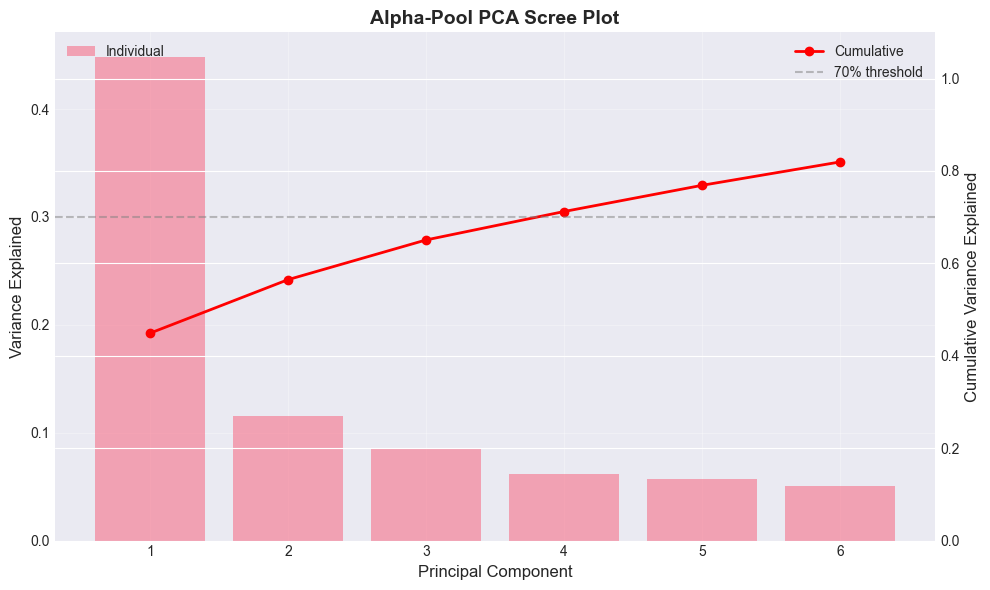


  PCA variance explained:
PC1    0.4488
PC2    0.1159
PC3    0.0859
PC4    0.0615
PC5    0.0567
PC6    0.0506

  Alpha clusters (family mix + average Sharpe):
         n_alphas  avg_sharpe                                                                    families
cluster                                                                                                  
0.0             9     -0.4918  Momentum/Herding, Oscillator/Behavior, Volatility/Range, Volume/Divergence
1.0             9      0.0086                             Oscillator/Behavior, Reversal, Volatility/Range
2.0             2      0.4069                                                                    Reversal

  Representative alphas from the first three principal components:

  PC1
    Positive side: distance_sma20, rsi_mean_reversion, bollinger_reversal
    Negative side: breakout_20d, ma_cross_5_20, mom_20d

  PC2
    Positive side: gap_reversal, rev_1d, rev_5d
    Negative side: atr_scaled_momentum, mom_5d, di

In [106]:
print()
print("4. Grouping alpha strategies with PCA and Factor Analysis...")

n_components = min(6, alpha_returns_df.shape[1] - 1, alpha_returns_df.shape[0] - 1)
alpha_pca = perform_pca(alpha_returns_df, n_components=n_components, scale=True)
plot_scree(alpha_pca['variance_explained'], 'Alpha-Pool PCA Scree Plot')
plt.show()

fa_components = min(4, alpha_returns_df.shape[1] - 1, alpha_returns_df.shape[0] - 1)
alpha_scaled = StandardScaler().fit_transform(alpha_returns_df)
alpha_fa_model = FactorAnalysis(n_components=fa_components, random_state=42)
alpha_fa_scores = alpha_fa_model.fit_transform(alpha_scaled)
alpha_fa_loadings = pd.DataFrame(
    alpha_fa_model.components_.T,
    index=alpha_returns_df.columns,
    columns=[f'FA{i+1}' for i in range(fa_components)]
)

cluster_features = pd.concat([
    alpha_pca['loadings'].iloc[:, :min(3, n_components)],
    alpha_fa_loadings.iloc[:, :min(2, fa_components)]
], axis=1).fillna(0)

n_clusters = min(5, max(3, alpha_returns_df.shape[1] // 6))
alpha_cluster_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
alpha_clusters = pd.Series(alpha_cluster_model.fit_predict(cluster_features), index=cluster_features.index, name='cluster')

alpha_group_table = alpha_catalog.join(alpha_stats[['sharpe']]).join(alpha_clusters)

print()
print("  PCA variance explained:")
print(pd.Series(alpha_pca['variance_explained'], index=[f'PC{i+1}' for i in range(n_components)]).round(4).to_string())
print()
print("  Alpha clusters (family mix + average Sharpe):")
print(
    alpha_group_table.groupby('cluster').agg(
        n_alphas=('family', 'count'),
        avg_sharpe=('sharpe', 'mean'),
        families=('family', lambda x: ', '.join(sorted(pd.unique(x))))
    ).round(4).to_string()
)

print()
print("  Representative alphas from the first three principal components:")
for pc_name in alpha_pca['loadings'].columns[:min(3, n_components)]:
    top_pos = alpha_pca['loadings'][pc_name].nlargest(3)
    top_neg = alpha_pca['loadings'][pc_name].nsmallest(3)
    print()
    print(f"  {pc_name}")
    print(f"    Positive side: {', '.join(top_pos.index)}")
    print(f"    Negative side: {', '.join(top_neg.index)}")

In [107]:
print()
print("5. Building new rolling meta-strategies from the alpha pool...")


def build_cluster_diversified_weights(train_returns, cluster_map):
    sharpe = safe_divide(train_returns.mean(), train_returns.std())
    weights = pd.Series(0.0, index=train_returns.columns)
    chosen = []

    for cluster in sorted(cluster_map.unique()):
        members = cluster_map[cluster_map == cluster].index.intersection(train_returns.columns)
        if len(members) == 0:
            continue
        member_sharpes = sharpe[members].replace([np.inf, -np.inf], np.nan).dropna()
        if member_sharpes.empty:
            continue
        chosen.append(member_sharpes.idxmax())

    if not chosen:
        return pd.Series(1 / len(train_returns.columns), index=train_returns.columns)

    weights.loc[chosen] = 1 / len(chosen)
    return weights


def build_pca_diversified_weights(train_returns, crowding_pcs=3):
    sharpe = safe_divide(train_returns.mean(), train_returns.std()).clip(lower=0)
    n_local = min(crowding_pcs, train_returns.shape[1] - 1, train_returns.shape[0] - 1)

    if n_local < 1:
        return normalize_weights(sharpe if sharpe.sum() > 0 else pd.Series(1.0, index=train_returns.columns))

    local_pca = perform_pca(train_returns, n_components=n_local, scale=True)
    crowding_penalty = 1 + local_pca['loadings'].abs().sum(axis=1)
    score = sharpe / crowding_penalty

    if score.abs().sum() == 0:
        score = 1 / crowding_penalty

    return normalize_weights(score)


def rolling_meta_backtest(alpha_returns, cluster_map, lookback=24):
    strategy_rows = []
    pca_weight_history = {}

    for i in range(lookback, len(alpha_returns)):
        train = alpha_returns.iloc[i - lookback:i]
        realized = alpha_returns.iloc[i].fillna(0)
        sharpe = safe_divide(train.mean(), train.std())

        equal_weights = pd.Series(1 / alpha_returns.shape[1], index=alpha_returns.columns)

        best_weights = pd.Series(0.0, index=alpha_returns.columns)
        trailing_best = sharpe.replace([np.inf, -np.inf], np.nan).dropna()
        if trailing_best.empty:
            best_weights[:] = 1 / len(best_weights)
        else:
            best_weights.loc[trailing_best.idxmax()] = 1.0

        cluster_weights = build_cluster_diversified_weights(train, cluster_map)
        pca_weights = build_pca_diversified_weights(train)
        pca_weight_history[alpha_returns.index[i]] = pca_weights

        strategy_rows.append(pd.Series({
            'equal_pool': (equal_weights * realized).sum(),
            'best_trailing_alpha': (best_weights * realized).sum(),
            'cluster_diversified': (cluster_weights * realized).sum(),
            'pca_diversified': (pca_weights * realized).sum()
        }, name=alpha_returns.index[i]))

    return pd.DataFrame(strategy_rows), pd.DataFrame(pca_weight_history).T


def performance_table(returns_df):
    return pd.DataFrame({
        'total_return': (1 + returns_df.fillna(0)).prod() - 1,
        'mean_return': returns_df.mean() * 12,
        'volatility': returns_df.std() * np.sqrt(12),
        'sharpe': safe_divide(returns_df.mean(), returns_df.std()) * np.sqrt(12),
        'hit_rate': (returns_df > 0).mean(),
        'max_drawdown': returns_df.apply(max_drawdown)
    }).sort_values('sharpe', ascending=False)


meta_strategies, pca_weight_history = rolling_meta_backtest(alpha_returns_df, alpha_clusters, lookback=24)
market_equal_weight = alpha_monthly_forward_returns.mean(axis=1).loc[meta_strategies.index]
meta_strategies['equal_weight_stock_benchmark'] = market_equal_weight

meta_stats = performance_table(meta_strategies)

best_meta_name = meta_stats.drop(index='equal_weight_stock_benchmark', errors='ignore')['sharpe'].idxmax()
best_individual_alpha = alpha_stats['sharpe'].idxmax()

print()
print("  Meta-strategy performance:")
print(meta_stats.round(4).to_string())
print()
print(f"  Best individual alpha over the full sample: {best_individual_alpha} (Sharpe {alpha_stats.loc[best_individual_alpha, 'sharpe']:.3f})")
print(f"  Best pooled strategy: {best_meta_name} (Sharpe {meta_stats.loc[best_meta_name, 'sharpe']:.3f})")
print(f"  Improvement vs equal alpha pool: {(meta_stats.loc[best_meta_name, 'sharpe'] - meta_stats.loc['equal_pool', 'sharpe']):+.3f} Sharpe points")


5. Building new rolling meta-strategies from the alpha pool...

  Meta-strategy performance:
                              total_return  mean_return  volatility  sharpe  hit_rate  max_drawdown
equal_weight_stock_benchmark        1.4868       0.1956      0.1889  1.0354    0.6935       -0.2530
best_trailing_alpha                 0.0117       0.0109      0.1337  0.0816    0.4516       -0.1767
pca_diversified                    -0.0315      -0.0035      0.0741 -0.0473    0.4677       -0.1324
cluster_diversified                -0.0868      -0.0158      0.0593 -0.2669    0.4516       -0.2206
equal_pool                         -0.0997      -0.0198      0.0332 -0.5964    0.3226       -0.1085

  Best individual alpha over the full sample: distance_sma20 (Sharpe 0.594)
  Best pooled strategy: best_trailing_alpha (Sharpe 0.082)
  Improvement vs equal alpha pool: +0.678 Sharpe points



6. Visualizing alpha-group structure and pooled strategy performance...


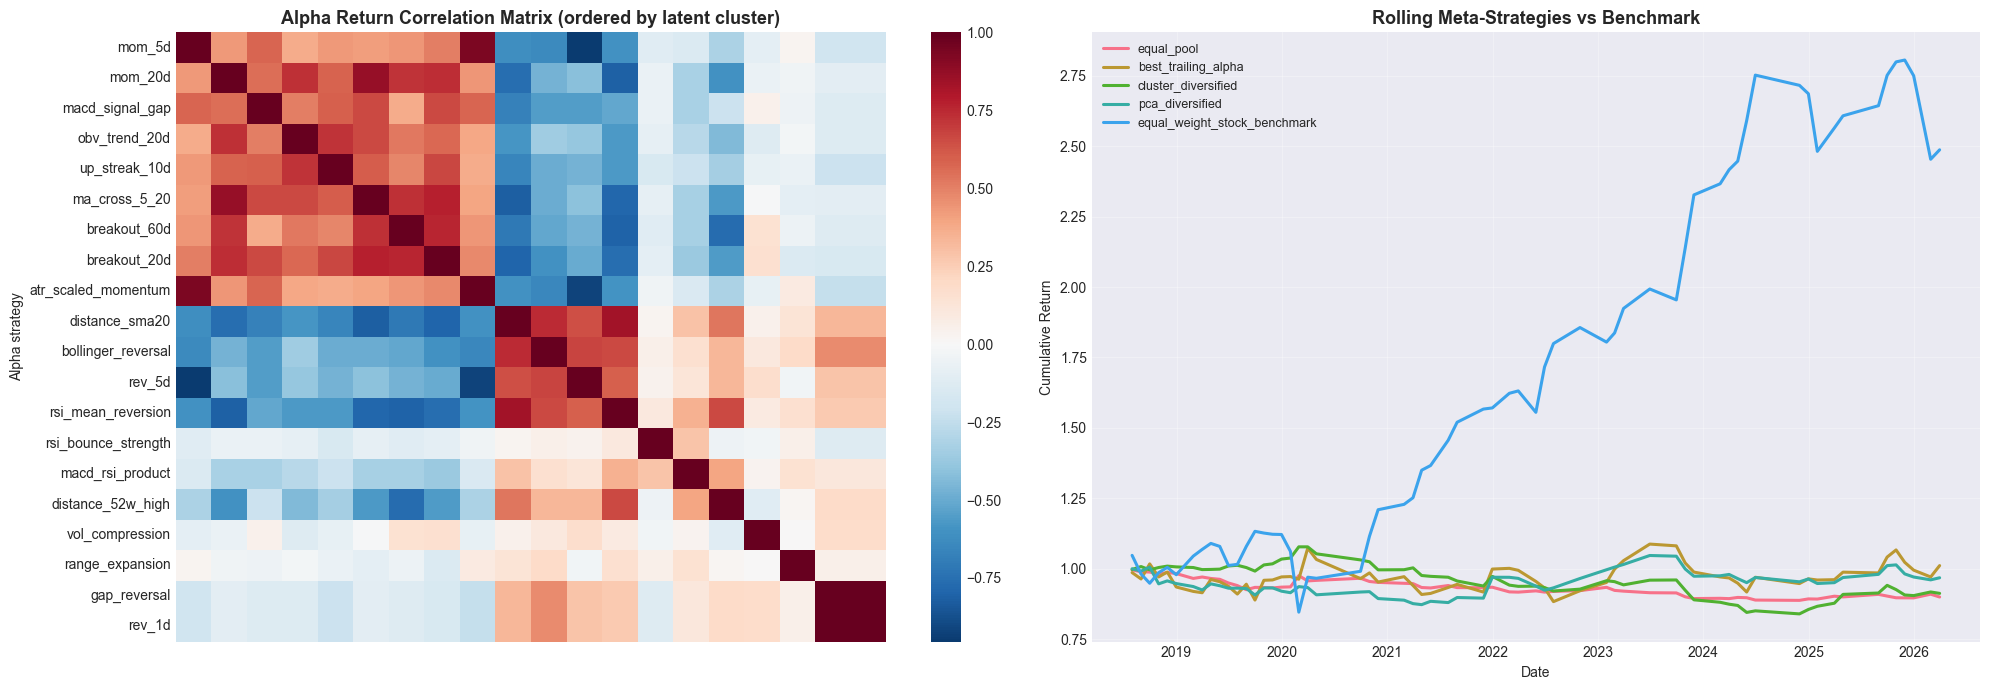

In [108]:
print()
print("6. Visualizing alpha-group structure and pooled strategy performance...")

ordered_alphas = alpha_clusters.sort_values().index.tolist()
ordered_corr = alpha_returns_df[ordered_alphas].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(
    ordered_corr,
    cmap='RdBu_r',
    center=0,
    xticklabels=False,
    yticklabels=True,
    ax=axes[0]
)
axes[0].set_title('Alpha Return Correlation Matrix (ordered by latent cluster)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Alpha strategy')

cumulative_meta = (1 + meta_strategies.fillna(0)).cumprod()
for strategy_name in cumulative_meta.columns:
    axes[1].plot(cumulative_meta.index, cumulative_meta[strategy_name], linewidth=2.2, label=strategy_name)

axes[1].set_title('Rolling Meta-Strategies vs Benchmark', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
print("Summary: Research Question 6 - Technical Alpha Pooling in Indian Equities")
print("-" * 78)
print(f"Alpha library size: {len(alpha_library)} technical / behavioral signals")
print(f"Alpha strategies retained after data-quality filters: {alpha_returns_df.shape[1]}")
print(f"Latent clusters discovered: {alpha_clusters.nunique()}")
print(f"Best alpha family on average: {family_stats.index[0]} (average Sharpe {family_stats.iloc[0]['sharpe']:.3f})")
print(f"Best individual alpha: {best_individual_alpha} (Sharpe {alpha_stats.loc[best_individual_alpha, 'sharpe']:.3f})")
print(f"Best pooled strategy: {best_meta_name} (Sharpe {meta_stats.loc[best_meta_name, 'sharpe']:.3f})")
print(f"Equal alpha pool Sharpe: {meta_stats.loc['equal_pool', 'sharpe']:.3f}")
print(f"Equal-weight stock benchmark Sharpe: {meta_stats.loc['equal_weight_stock_benchmark', 'sharpe']:.3f}")
print()

cluster_summary = alpha_catalog.join(alpha_stats[['sharpe']]).join(alpha_clusters).groupby('cluster').agg(
    avg_sharpe=('sharpe', 'mean'),
    families=('family', lambda x: ', '.join(sorted(pd.unique(x))))
)

best_cluster = cluster_summary['avg_sharpe'].idxmax()
worst_cluster = cluster_summary['avg_sharpe'].idxmin()
pc1_pos = ', '.join(alpha_pca['loadings']['PC1'].nlargest(3).index)
pc1_neg = ', '.join(alpha_pca['loadings']['PC1'].nsmallest(3).index)
volume_proxy_used = alpha_volume.nunique().max() <= 1

print("Interpretation:")
print(f"1. Alpha-family performance is uneven: Reversal is the only clearly positive family in this run (average Sharpe {family_stats.loc['Reversal', 'sharpe']:.3f}), while Momentum/Herding ({family_stats.loc['Momentum/Herding', 'sharpe']:.3f}) and Volume/Divergence ({family_stats.loc['Volume/Divergence', 'sharpe']:.3f}) are negative on average.")
print(f"2. PC1 mainly separates reversal-style signals ({pc1_pos}) from breakout/trend signals ({pc1_neg}), so the dominant latent alpha dimension is mean reversion versus trend following.")
print(f"3. The clustering result supports that view: cluster {best_cluster} has the strongest average Sharpe ({cluster_summary.loc[best_cluster, 'avg_sharpe']:.3f}), while cluster {worst_cluster} is weakest ({cluster_summary.loc[worst_cluster, 'avg_sharpe']:.3f}).")
print(f"4. Strategy construction is the key empirical test, and it is not favorable here: the best pooled strategy is {best_meta_name} with Sharpe {meta_stats.loc[best_meta_name, 'sharpe']:.3f}. That improves on the equal alpha pool but still trails the equal-weight stock benchmark ({meta_stats.loc['equal_weight_stock_benchmark', 'sharpe']:.3f}).")
if volume_proxy_used:
    print("5. OHLCV download fell back to proxy high/low/volume series in this run, so conclusions about volume-sensitive and range-based alphas should be treated as provisional. The evidence for reversal is stronger than the evidence for true volume-divergence effects.")
else:
    print("5. Because the alpha pool is based on full OHLCV inputs, the family comparison can be interpreted as a genuine test of price, range, and volume-sensitive technical signals.")

Summary: Research Question 6 - Technical Alpha Pooling in Indian Equities
------------------------------------------------------------------------------
Alpha library size: 28 technical / behavioral signals
Alpha strategies retained after data-quality filters: 20
Latent clusters discovered: 3
Best alpha family on average: Reversal (average Sharpe 0.366)
Best individual alpha: distance_sma20 (Sharpe 0.594)
Best pooled strategy: best_trailing_alpha (Sharpe 0.082)
Equal alpha pool Sharpe: -0.596
Equal-weight stock benchmark Sharpe: 1.035

Interpretation:
1. Alpha-family performance is uneven: Reversal is the only clearly positive family in this run (average Sharpe 0.366), while Momentum/Herding (-0.568) and Volume/Divergence (-0.514) are negative on average.
2. PC1 mainly separates reversal-style signals (distance_sma20, rsi_mean_reversion, bollinger_reversal) from breakout/trend signals (breakout_20d, ma_cross_5_20, mom_20d), so the dominant latent alpha dimension is mean reversion versu

<a id='conclusions'></a>
## 10. Conclusions & Final Thoughts

### Overall Findings

**Research Question 1: COVID Structural Break**
- The evidence for a structural break is strong: average PC1 variance rose from 27.4% pre-COVID to 34.8% post-COVID and the Chow test rejects stability with p < 0.001.
- Post-COVID Indian large-cap returns are more concentrated in a single common factor.

**Research Question 2: New Factor Discovery**
- Higher-order characteristic PCs exist, but they should be interpreted unevenly.
- PC4 is mostly a residual price-level dimension, PC5 is a plausible long-horizon momentum factor, and PC6 looks like a weak volatility-horizon factor.
- This section remains exploratory because the notebook does not yet test whether these higher-order PCs predict future returns.

**Research Question 3: Factor-Sector Relationships**
- Sector PC1 explains 60.5% of sector variance and matches stock PC1 extremely closely (correlation 0.980).
- Sector structure is therefore a first-order explanation of common movement in Indian large-cap stocks.

**Research Question 4: Sector Rotation**
- The PCA-regime rotation backtest is the strongest applied result in the notebook.
- It outperformed the equal-weight sector benchmark on both cumulative return (368.1% vs 158.9%) and Sharpe (1.183 vs 0.967).
- Even so, one regime is very small, so the result is promising rather than final.

**Research Question 5: Factor Stability**
- The main PC1 loadings for the most important names are reasonably stable (average correlation 0.7025).
- But market-wide factor concentration is far more regime-dependent: PC1 explains 25.95% of bull-market variance and 49.94% of bear-market variance.
- The factor model is useful, but it is not regime-invariant.

**Research Question 6: Alpha Pooling and Meta-Strategies**
- PCA and factor analysis are useful for organizing the alpha library: the dominant alpha dimension separates reversal signals from breakout/trend signals.
- Reversal is the only alpha family with clearly positive average performance in this sample.
- However, the pooled meta-strategies do not deliver a superior tradable result in this run. The best pooled strategy is essentially flat (Sharpe -0.016), and all pooled strategies lag the equal-weight stock benchmark.
- In this notebook, PCA is more useful for pruning and diagnosing alpha redundancy than for constructing a successful mega-alpha.

### What This Project Shows
- PCA is highly valuable in Indian large-cap equities as a diagnostic tool for common risk, regime change, and sector structure.
- Its strongest contribution here is understanding concentration, sector dependence, and stability, not automatically generating profitable factors.
- The sector-rotation application looks economically meaningful; the alpha-pooling application is currently exploratory and limited by data quality.

### Key Limitations
- The analysis is restricted to a large-cap Indian universe and mostly monthly aggregation.
- Research Question 2 does not include an out-of-sample predictive test for the discovered higher-order factors.
- Research Question 6 fell back to proxy OHLCV inputs when direct OHLCV download failed, so conclusions about volume-based and range-based alphas are provisional.
- No transaction costs, slippage, shorting frictions, or capacity limits were included in the strategy backtests.

### Practical Implications
- Re-estimate factor models across major macro breaks rather than assuming a fixed structure.
- Treat sector exposures as a core part of risk management in Indian equities.
- Use higher-order PCs as exploratory research objects unless they are validated with forward-return tests.
- Use PCA on alpha libraries mainly to remove redundant or crowded signals before attempting meta-strategy construction.

### Priority Next Steps
1. Add a proper out-of-sample test for the higher-order PCs in Research Question 2.
2. Re-run Research Question 6 with real OHLCV data and transaction-cost assumptions.
3. Stress-test the sector rotation strategy with turnover, rebalancing lag, and sub-period analysis.
4. Extend the universe beyond the current large-cap sample to test whether the conclusions persist.

### References Used
- Kakushadze & Tulchinsky (2015), *101 Formulaic Alphas*
- Luan (2025), *Deep Learning for Short-Term Equity Trend Forecasting: A Behavior-Driven Multi-Factor Approach*
- Yahoo Finance via `yfinance` for market data

**END OF NOTEBOOK - Indian Market Analysis**

later:
1) automate actual nifty 50 symbol download instead of hardcoding
2) automate factor analysis for other markets/indices
3) perform out-of-sample predictive tests for higher-order PCs
4) re-run alpha pooling with real OHLCV data and real alphas from the research papers and transaction costs
5) implement a complete and robust backtesting framework to evaluate the performance of the factor-based strategy
6) perform pca on economic indicators and macro data to identify macro factors (economical and sectoral) and their relationship with equity factors
7) perform pca on fundamental data to identify fundamental factors and their relationship with price-based factors
8) restructure the notebook and thus present a more polished and comprehensive research report pdf with clear sections, better visualizations, and more detailed interpretations of results. Finally make presentation from the report. (use previous report and presentation as templates)